# ¿Qué es una base de datos en la nube? ¿En qué se diferencia de una base de datos tradicional?

Las **bases de datos Cloud**, tienen la particularidad de que la información no está almacenada en un equipo local, sino en **servidores**, a los que se puede acceder **a través de internet o de una red interna** en el caso de ser una nube privada.

Por lo demás, estas bases de datos almacenan los **mismos tipos de datos** que las BBDD locales.
El **beneficio**: El de la **computación en la nube** (velocidad, escalabilidad, agilidad, costos...)

# Soluciones **Cloud** en **Google** para **BBDD**

Veamos qué opciones nos ofrece Google Cloud

Menú -> Soluciones -> Bases de Datos

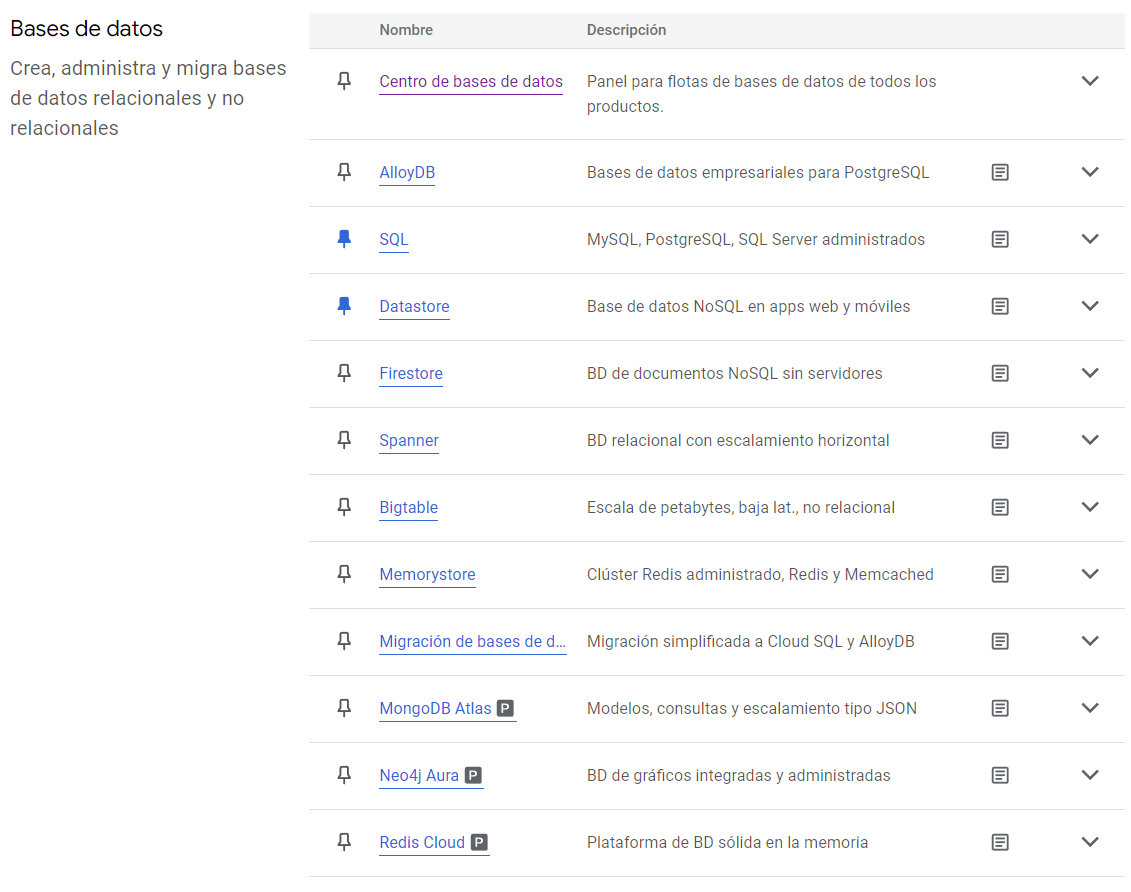











Existen dferentes soluciones, basadas en distintas bases de datos, SQL y NoSQL.
Algunas de las más destacables son:

- **SQL**: Bases de datos SQL, como MySQL, Postgre o SQL Server
- **Datastore**: Una base de datos NoSQL, basada en documentos pensada para apps web y móviles (facilmente escalable, alto rendimiento y orientada para desarrollar aplicaciones de este tipo).
- **BigTable**: También NoSQL, pensada para grandes volumenes de datos, con alta disponibilidad y baja latencia.
- **MongoBD Atlas**: Otra NoSQL. Capaz de manejar cargas de trabajo transaccionales, facilita la implementación, administración y escalabilidad de clústeres de bases de datos MongoBD. Pensada para desarrollo de apps web, análisis de datos y para IoT.
- **Neo4j**: Una BBDD  de grafos.
- **Redis**: Una base de datos con estructuras clave-valor.

# Oye... Y ¿qué era eso de bases de datos **SQL** y **NoSQL**?

SQL: Structured Query Languaje
NoSQL: Not Only SQL.

Las clásicas bases de datos **SQL**, que siempre son **relacionales**, están basadas en el **modelo entidad-relación** (o **modelo relacional**). Utilizan tablas donde cada fila representa una entidad y cada columna un atributo de dicha entidad.
Utilizan el **lenguaje SQL** y las relaciones se establecen mediante primary keys y foreign keys.
MySQL, Postgre, Oracle, SQL Server...

Las bases de datos **NoSQL** abarcan un **amplio abanico de sistemas de gestión de datos** que no necesariamente se basan en el sistema entidad-relación.
Existen diferentes modelos, como **clave-valor**, **documento**, **columna ancha**, **grafo**...
Son más **flexibles y escalables**, por lo que son una buena opción en el manejo de **grandes volúmenes de datos no estructurados o semiestructurados**.
- MongoDB, Cassandra, Redis, Amazon DynamoDB...


# Vamos a comenzar a trabajar con las **bases de datos Cloud**

Para ello, primero necesitamos tener algo de información ¿no?

Subamos un **dump de la base de datos** a **Google Storage**

El archivo que subiremos se llama ***dota.sql***

Un **dump de una base de datos** es una **copia de seguridad** de la base de datos en un momento específico en el tiempo. Esta copia de seguridad incluye la estructura de la base de datos (tablas, índices, vistas, etc.) y los datos almacenados en ella en ese momento.

**GOOGLE STORAGE** es un servicio de Google Cloud para **almacenamiento**. NO es una base de datos, es algo así como nuestro "**disco duro**" en la nube.

Menú -> Cloud Storage


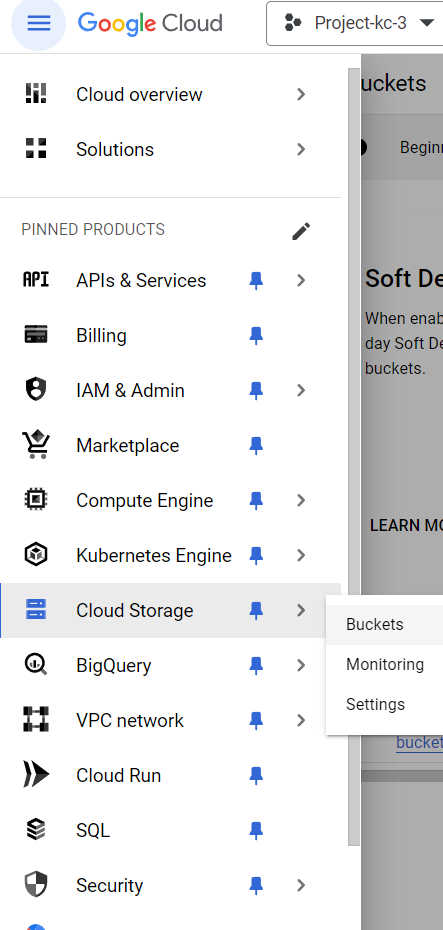



## Cloud Storage, funciona mediante **BUCKETS**

Los buckets (Contenedores en español), son las estructuras de almacenamiento que se utilizan en las distintas plataformas cloud (Como AWS o Google Cloud).
Podemos configurarlos en función del uso que vayamos a darles, disponibilidad, acceso, etc, como veremos a continuación.

### Vamos a **crear** nuestro primer **Bucket** y a **subir data**!

**1- Creamos un bucket:**

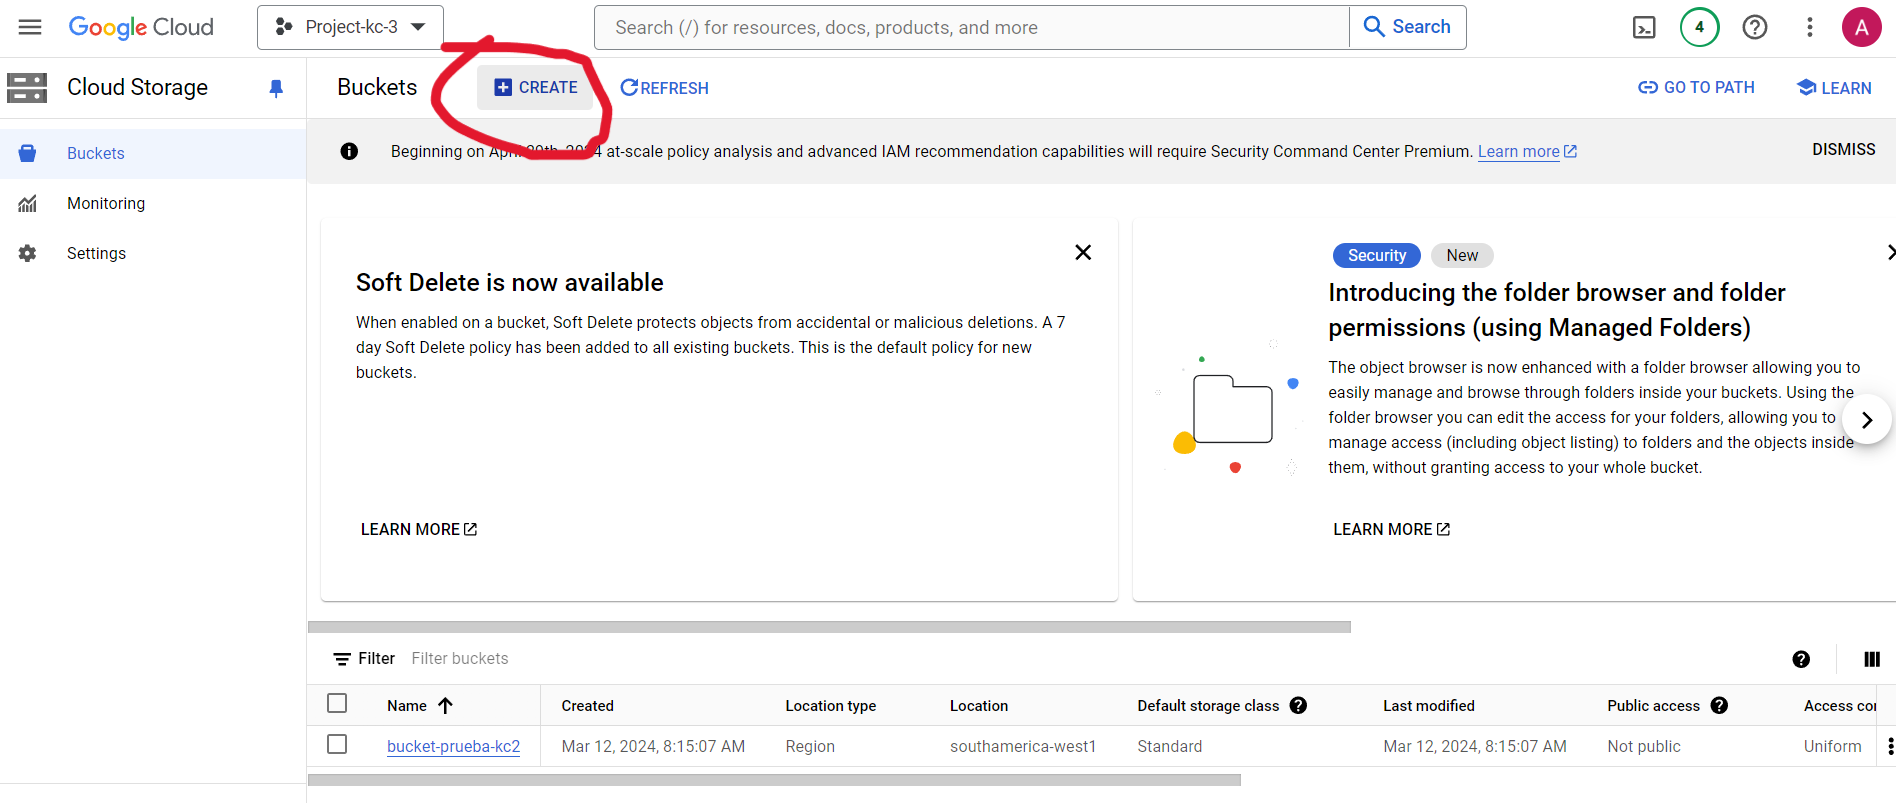

**2- Configuramos todas las opciones necesarias.**

**3- Una vez creado, veremos la página con los detalles del bucket:**

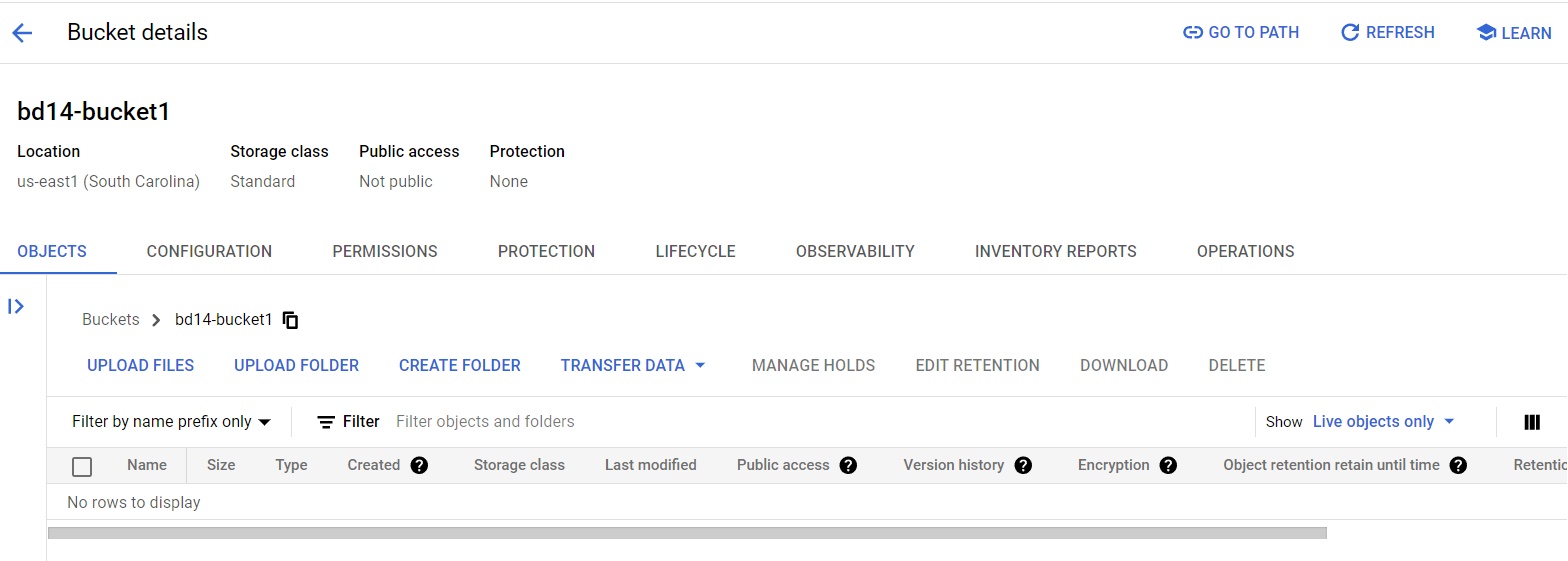

**4- Si todo fue bien, al ir atrás, nuestro nuevo bucket debe aparecer en la lista de buckets:**

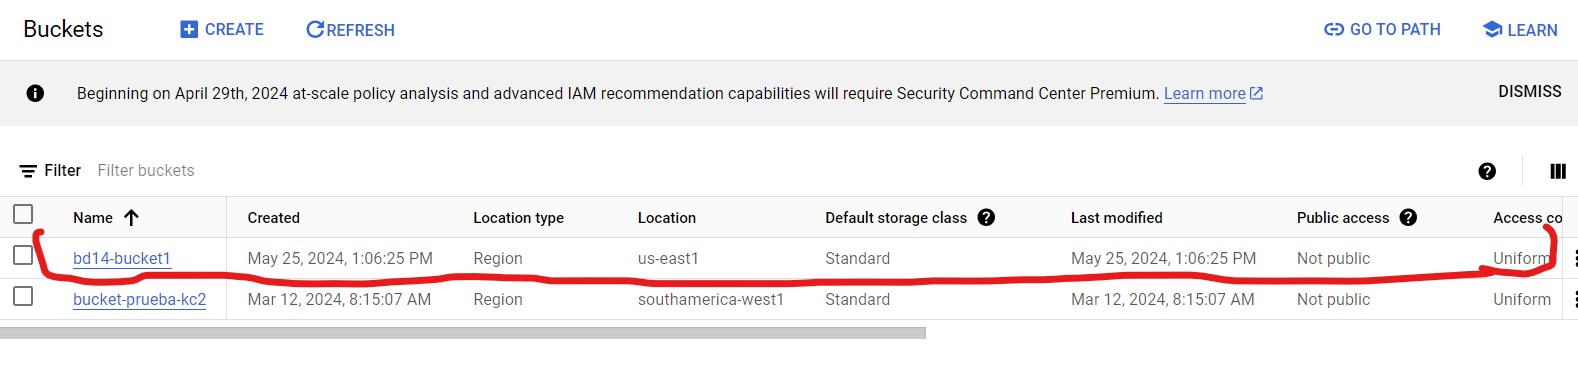

**5- Ahora, dentro del bucket que creamos, vamos a subir el dump de la base de datos. Para ello:**

  5.1- Hacemos click en "Upload Files":

  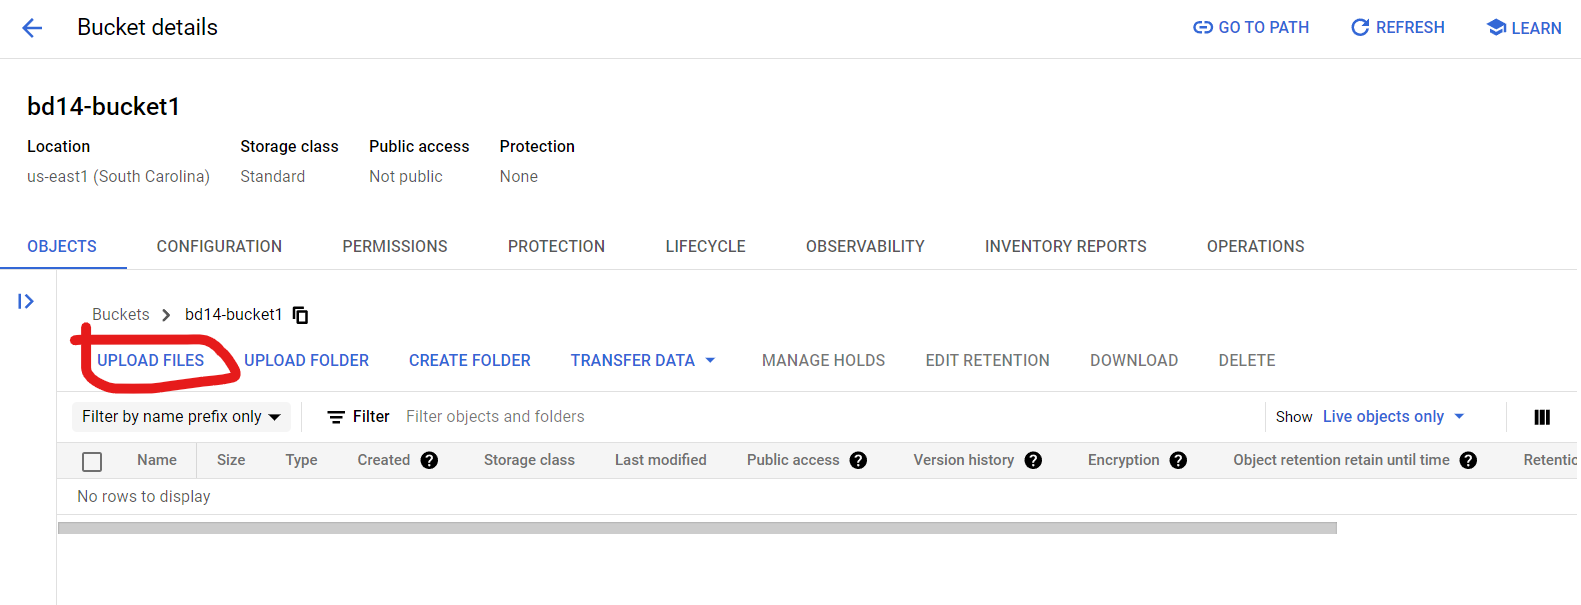

  5.2- En unos segundos el archivo aparecerá subido en el bucket:


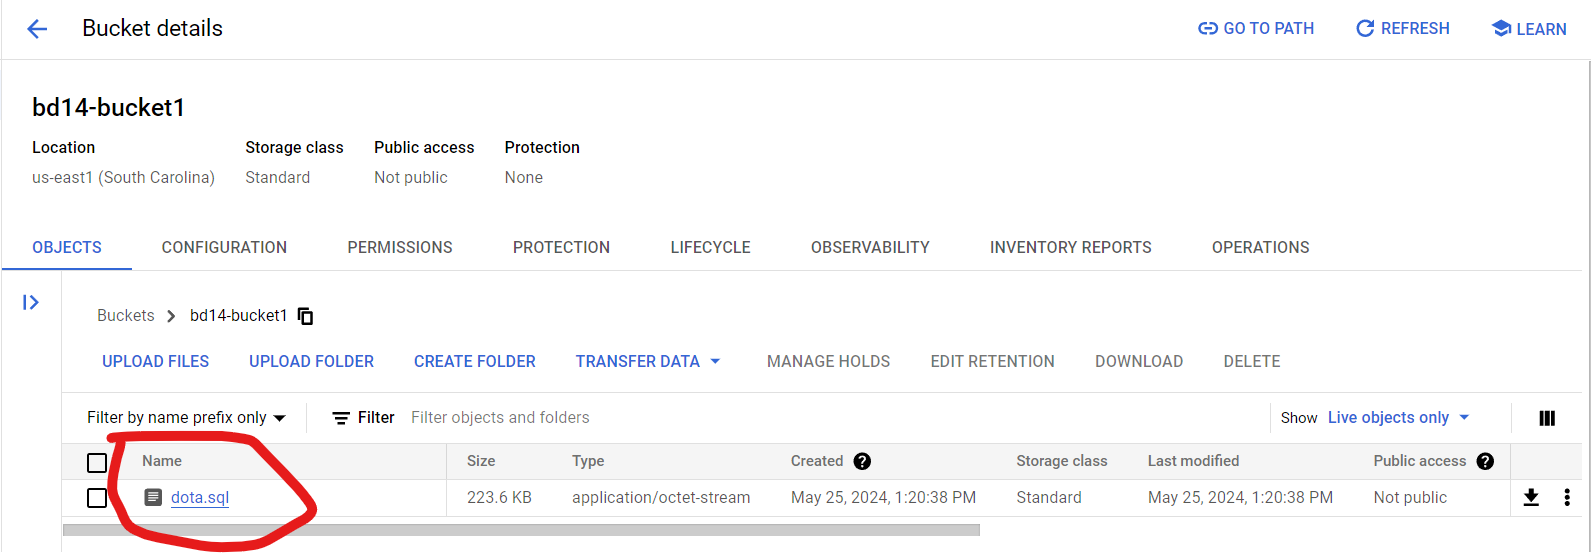



## Ahora, vamos a crear nuestra primera instancia de PostgreSQL

**NOTA IMPORTANTE**: Casi todos los pasos de lo que vamos a hacer es apificable y automatizable con el API de Cloud SQL y otras herramientas.

Primero que nada utilizaremos este mismo cuaderno de Colab para verificar que las configuraciones son correctas, para ello podemos ver cual es la **ip actual de este notebook** con !curl ipecho.net/plain

In [6]:
!curl ipecho.net/plain

35.197.120.210

# Comencemos con **SQL** -> **Google Cloud SQL**

**Google Cloud SQL** es un servicio de base de datos **totalmente administrado** que facilita la configuración, el mantenimiento, la administración y la administración de sus bases de datos relacionales MySQL y PostgreSQL en la nube.

Alojado en **Google Cloud Platform**, **Cloud SQL** proporciona una infraestructura de base de datos para aplicaciones que se ejecutan en cualquier lugar.

Es fácil de usar. No requiere ninguna instalación de software. Automatiza todas sus copias de seguridad, replicaciones, parches y actualizaciones, al tiempo que garantiza una disponibilidad superior al 99,95% en cualquier parte del mundo. Sus datos se cifran automáticamente y Cloud SQL cumple con SSAE 16, ISO 27001, PCI DSS v3.0 y HIPAA.

1- Vamos a Menú -> SQL -> **Create instance with your free credits**

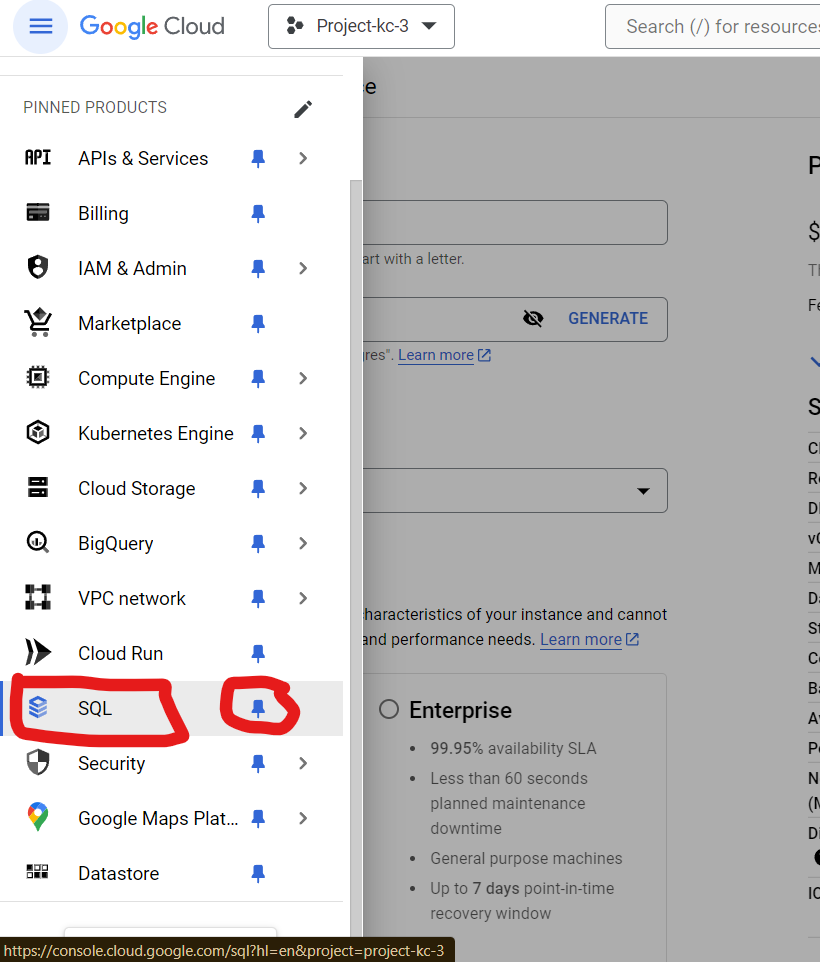


2- **Choose PostgreSQL** (->Enable API if not enabled)

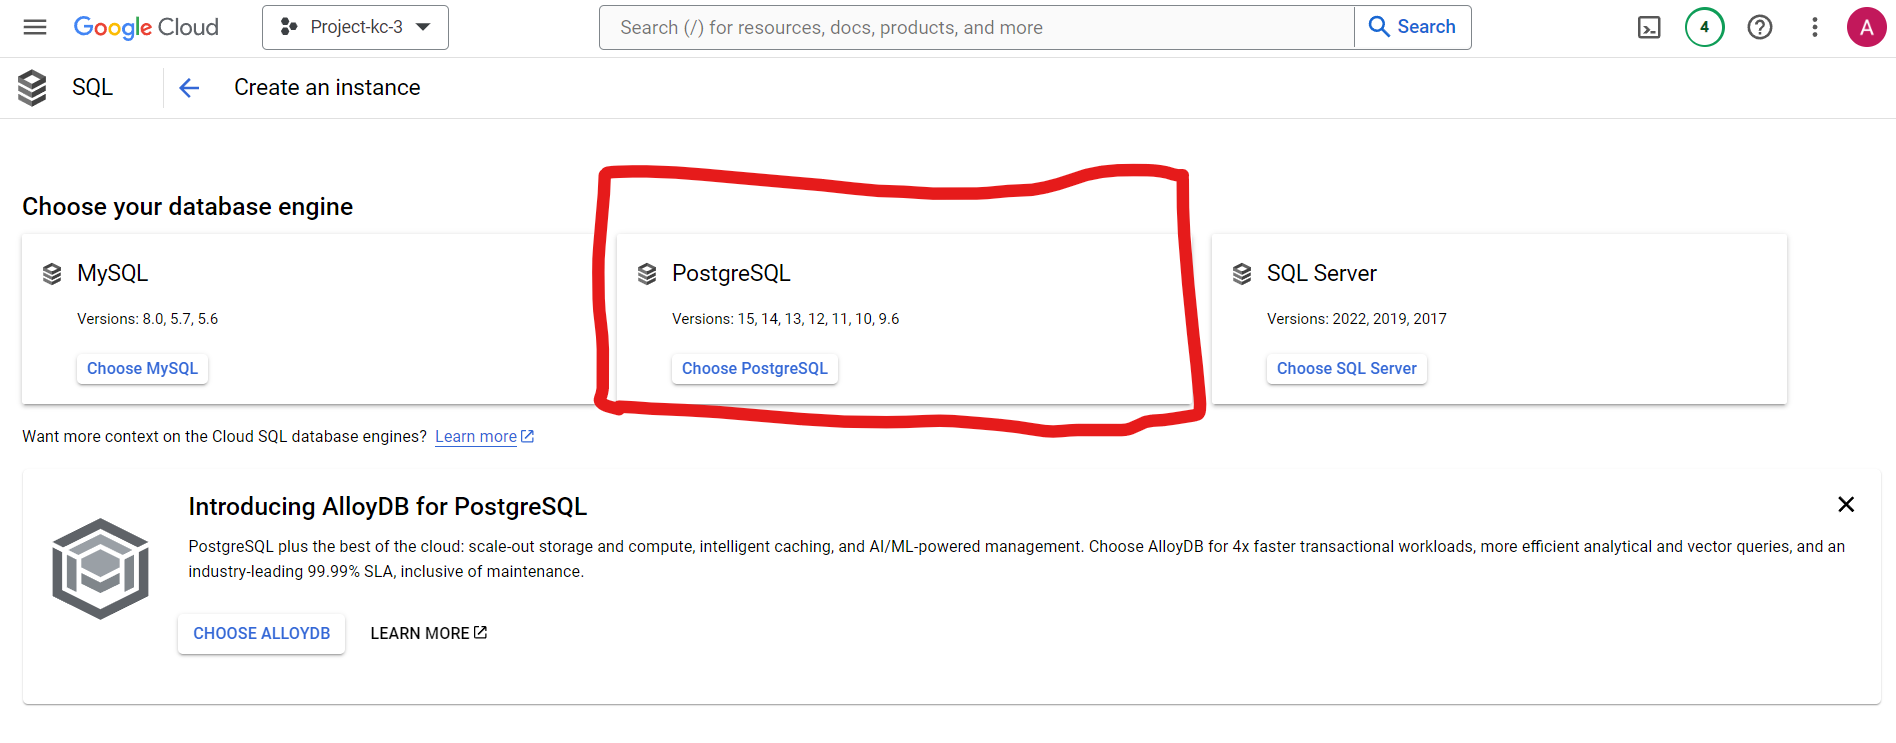

3- Configuramos la instancia de Postgre

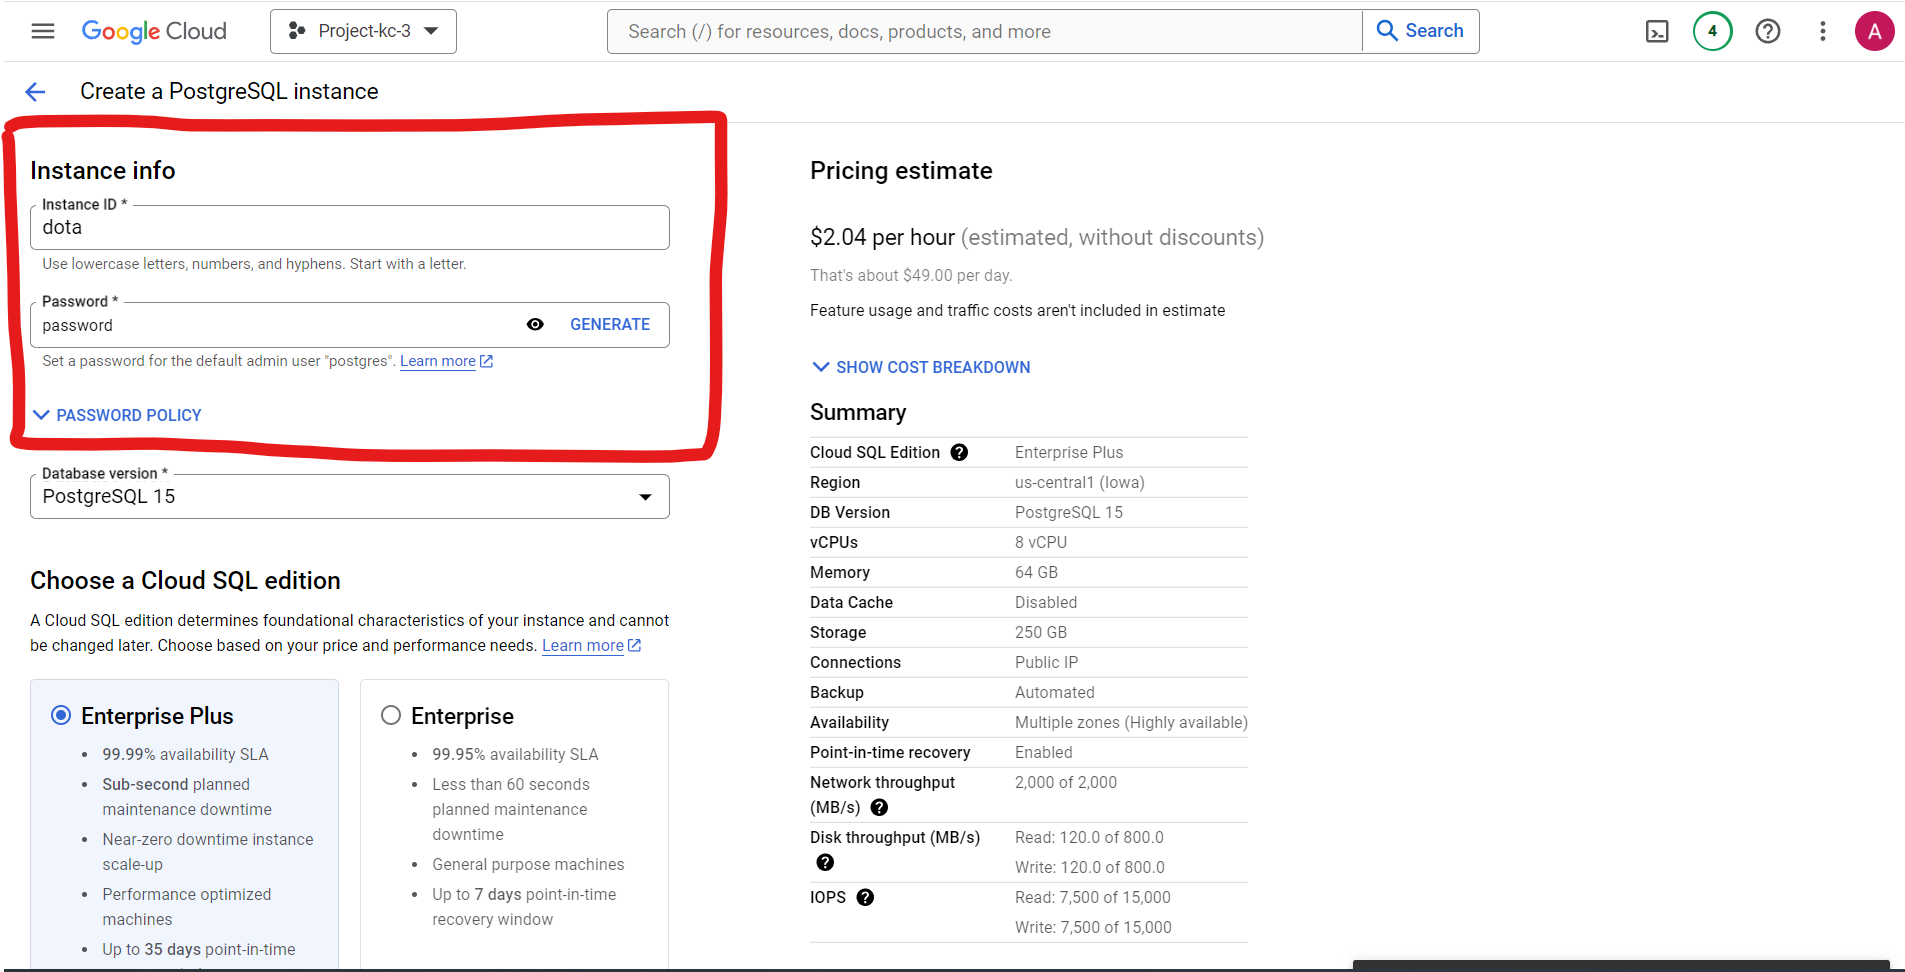

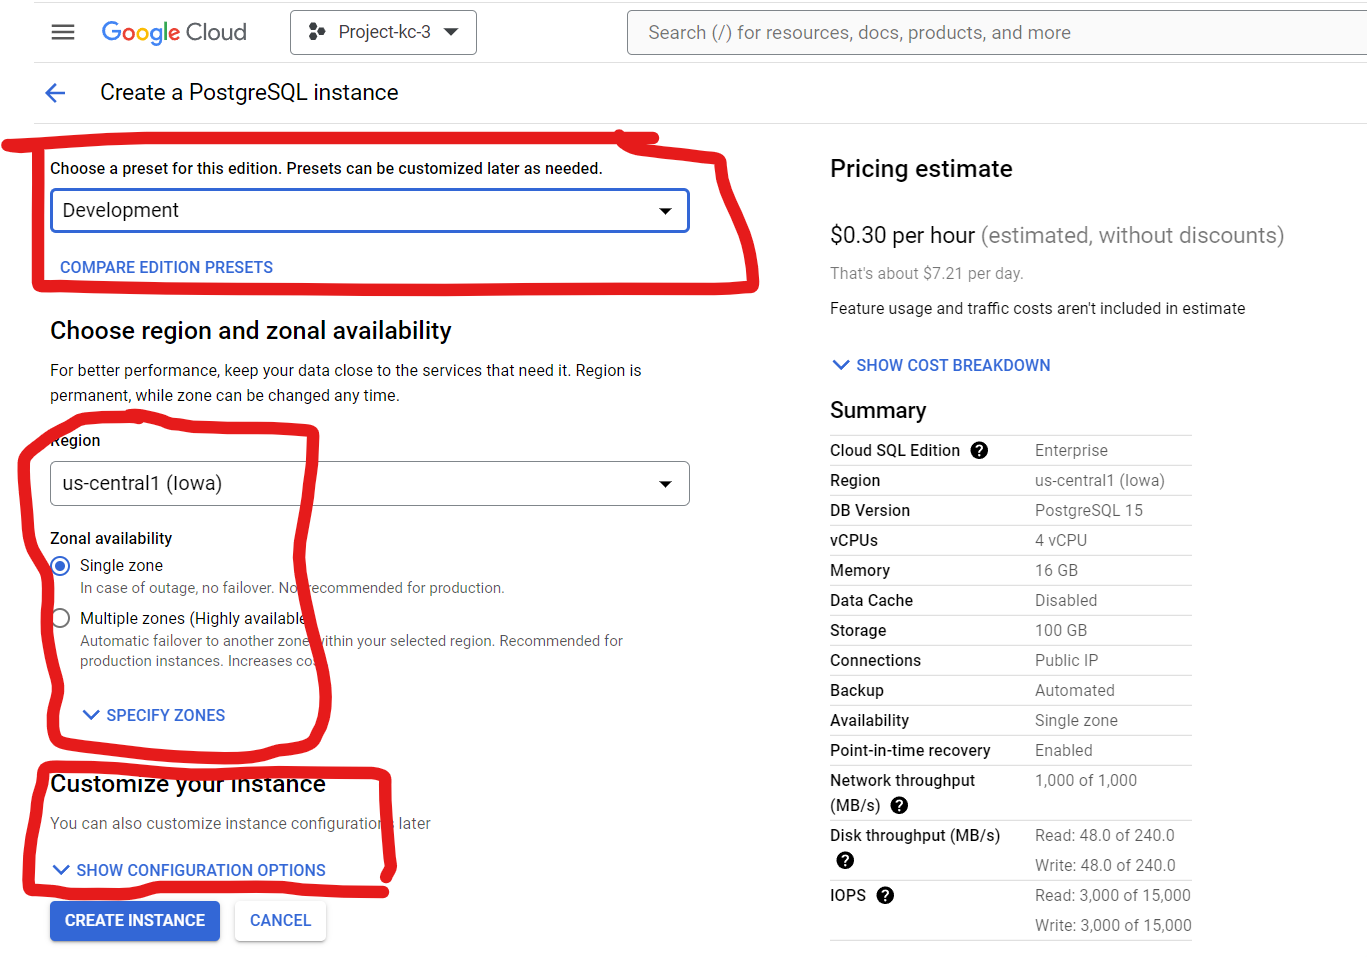

4- Dentro de las opciones, en **Connection**, seleccionamos **"Add a Network"**

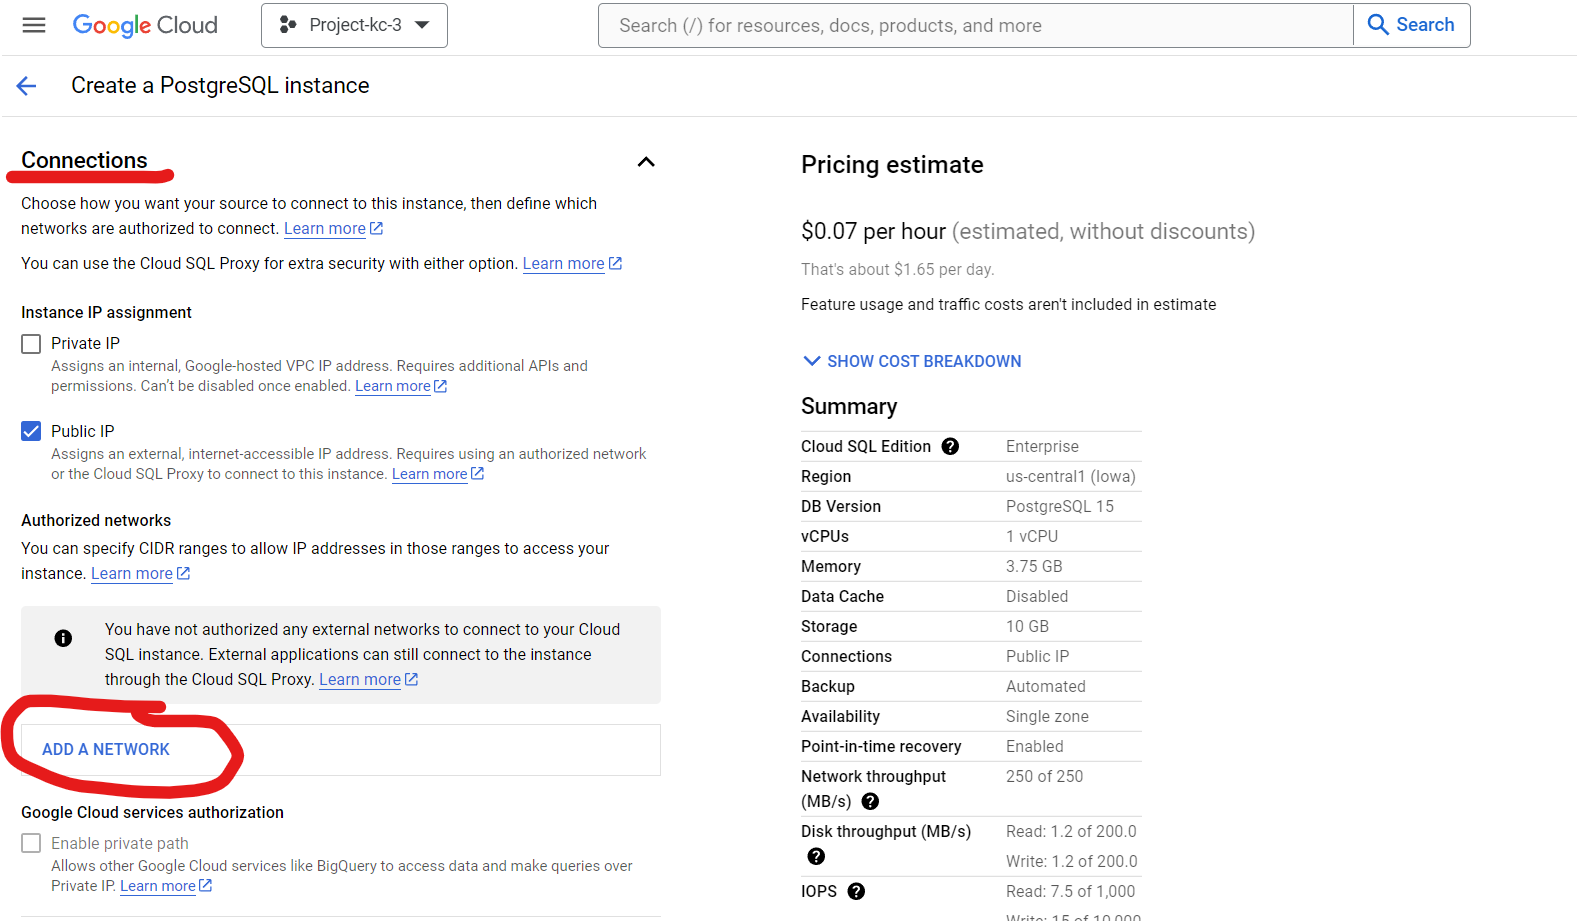


5- Introducimos la IP de nuestro notebook (nuestro cliente)

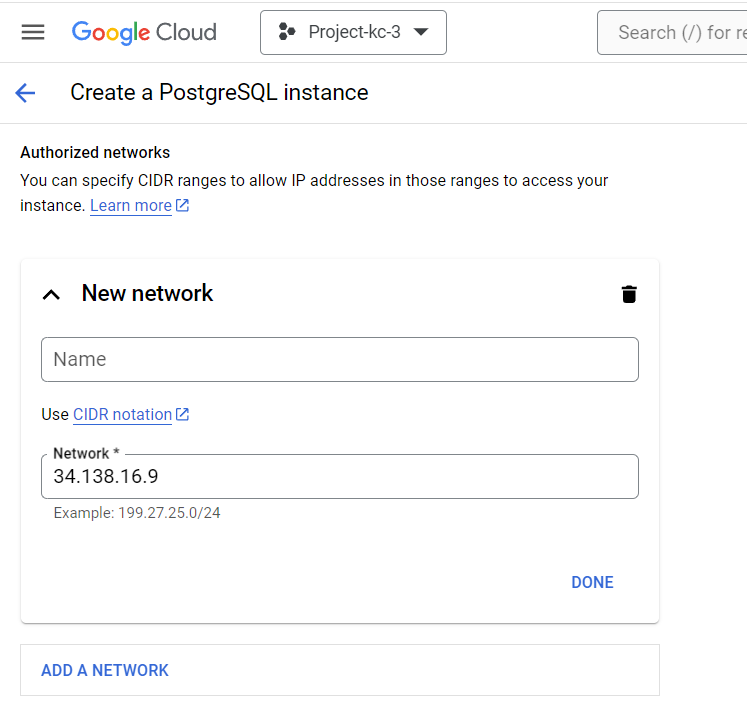


Ojo si abrimos a todo internet (0.0.0.0/0) nos saldra una advertencia importante:

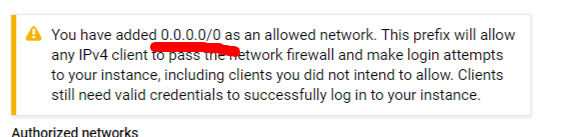

6-Una vez que hemos **creado la instancia de la base de datos**, nos encontramos la siguiente pantalla. **Creemos ahora un usuario para conectarnos e insertar los datos**:

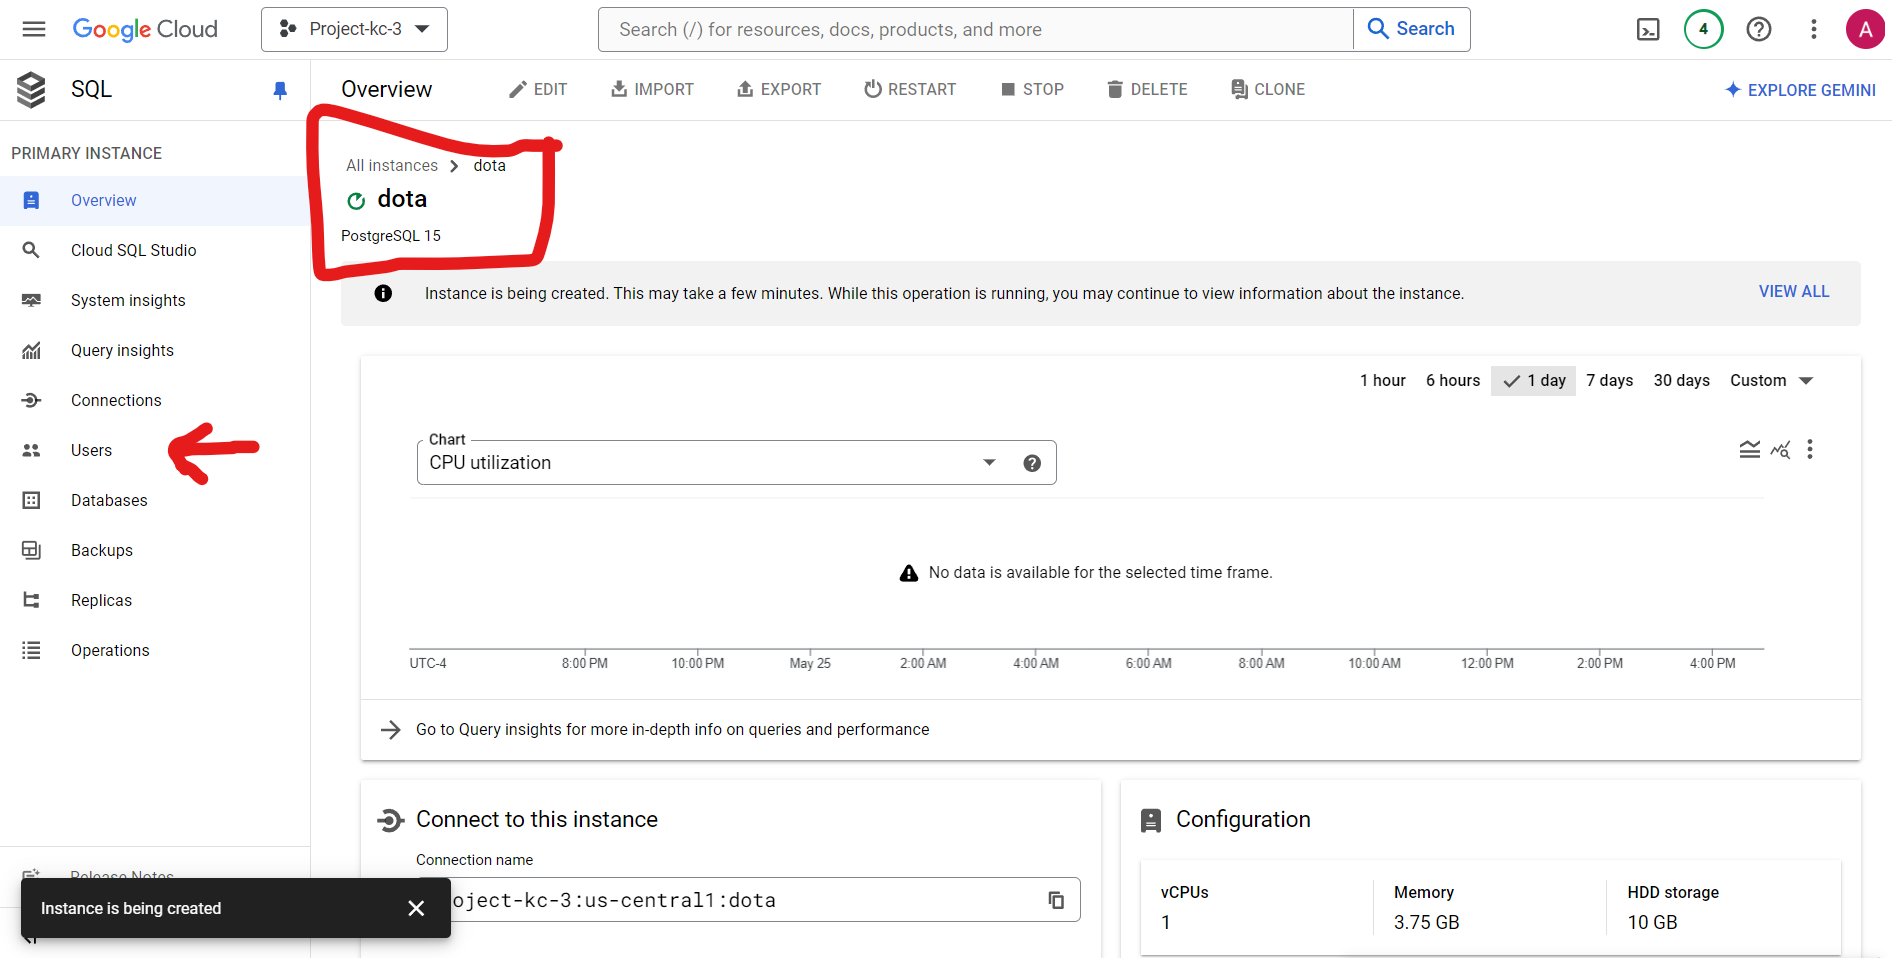

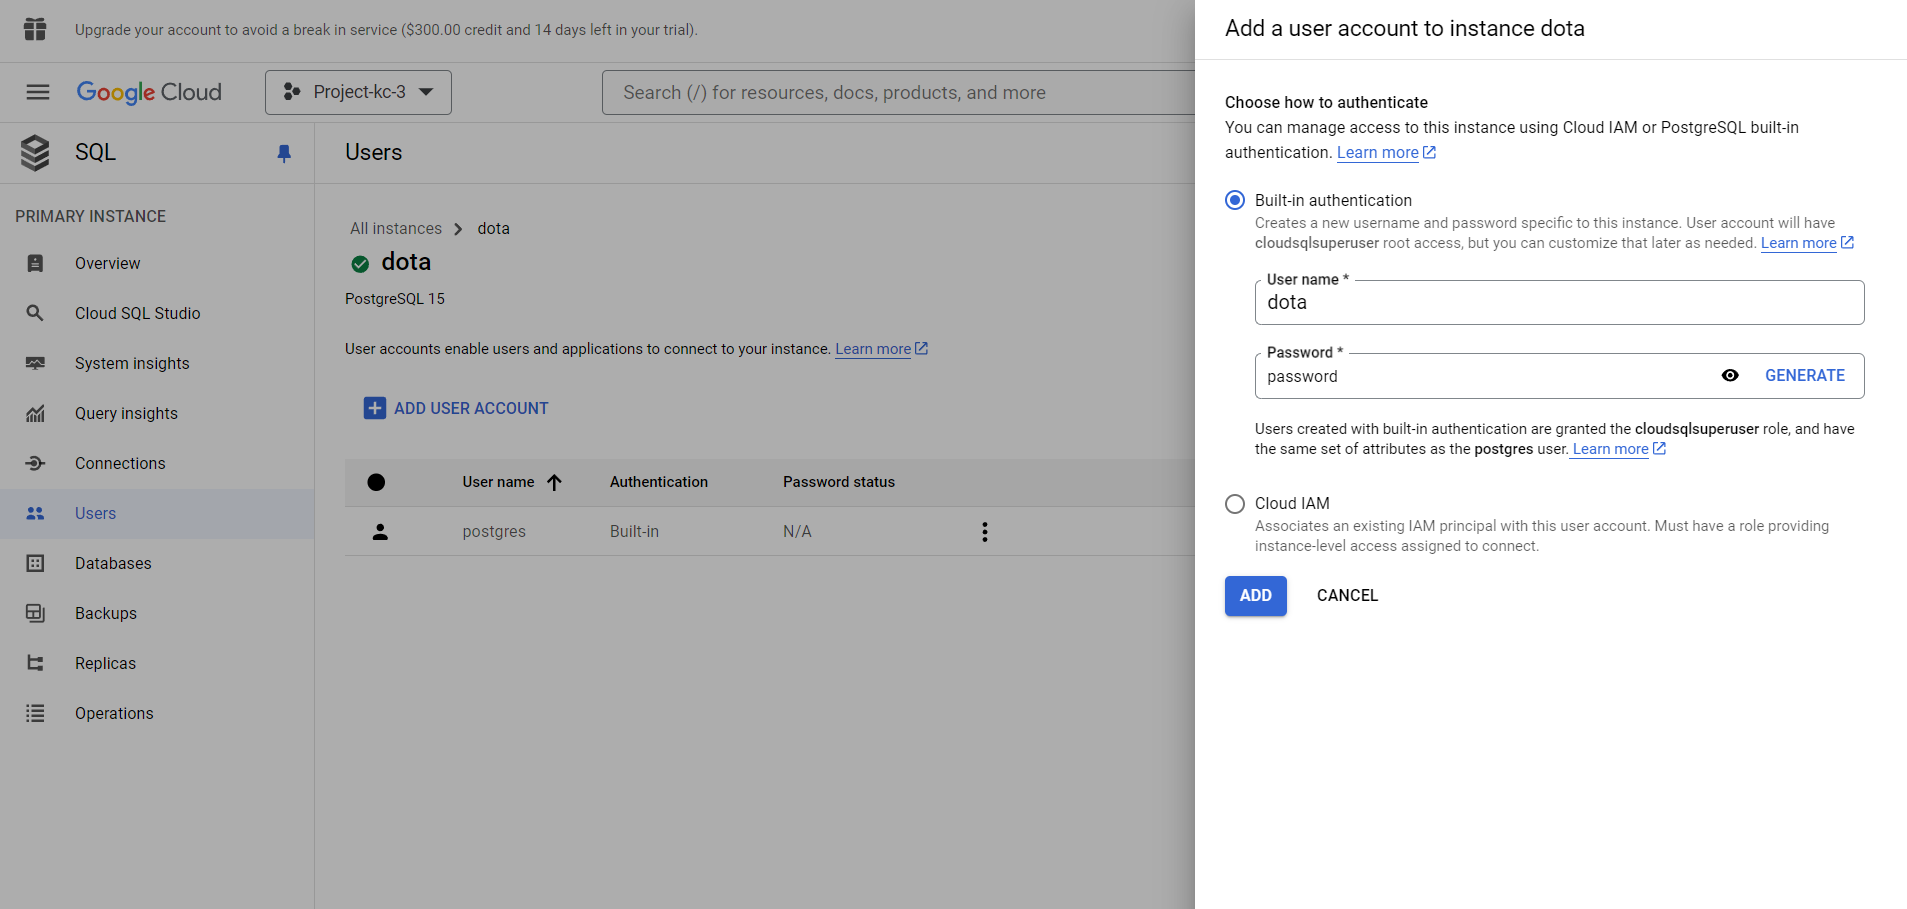

## Ahora sí, **agreguemos** los datos a nuestra nueva **base de datos** 🙌🙌

1- **Una vez terminada la creacion del servicio SQL deberiamos ver la marca verde en el dashboard y podemos entrar en "Importar datos":**


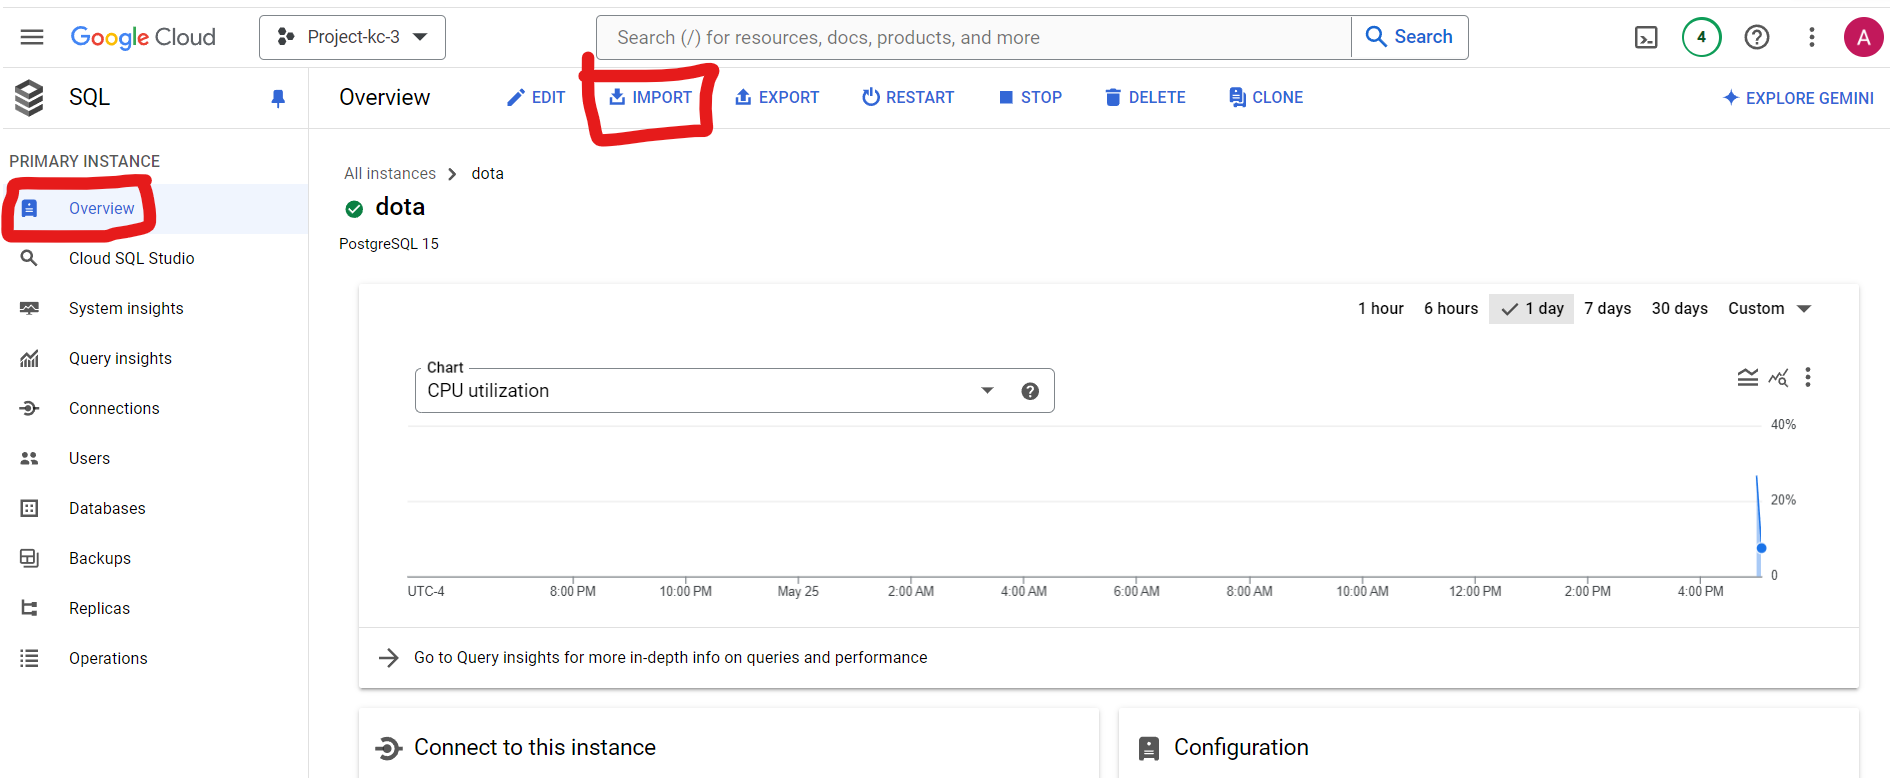

2- **Seleccionamos el bucket de origen de los datos y la base de datos en la que queremos cargarlos:**

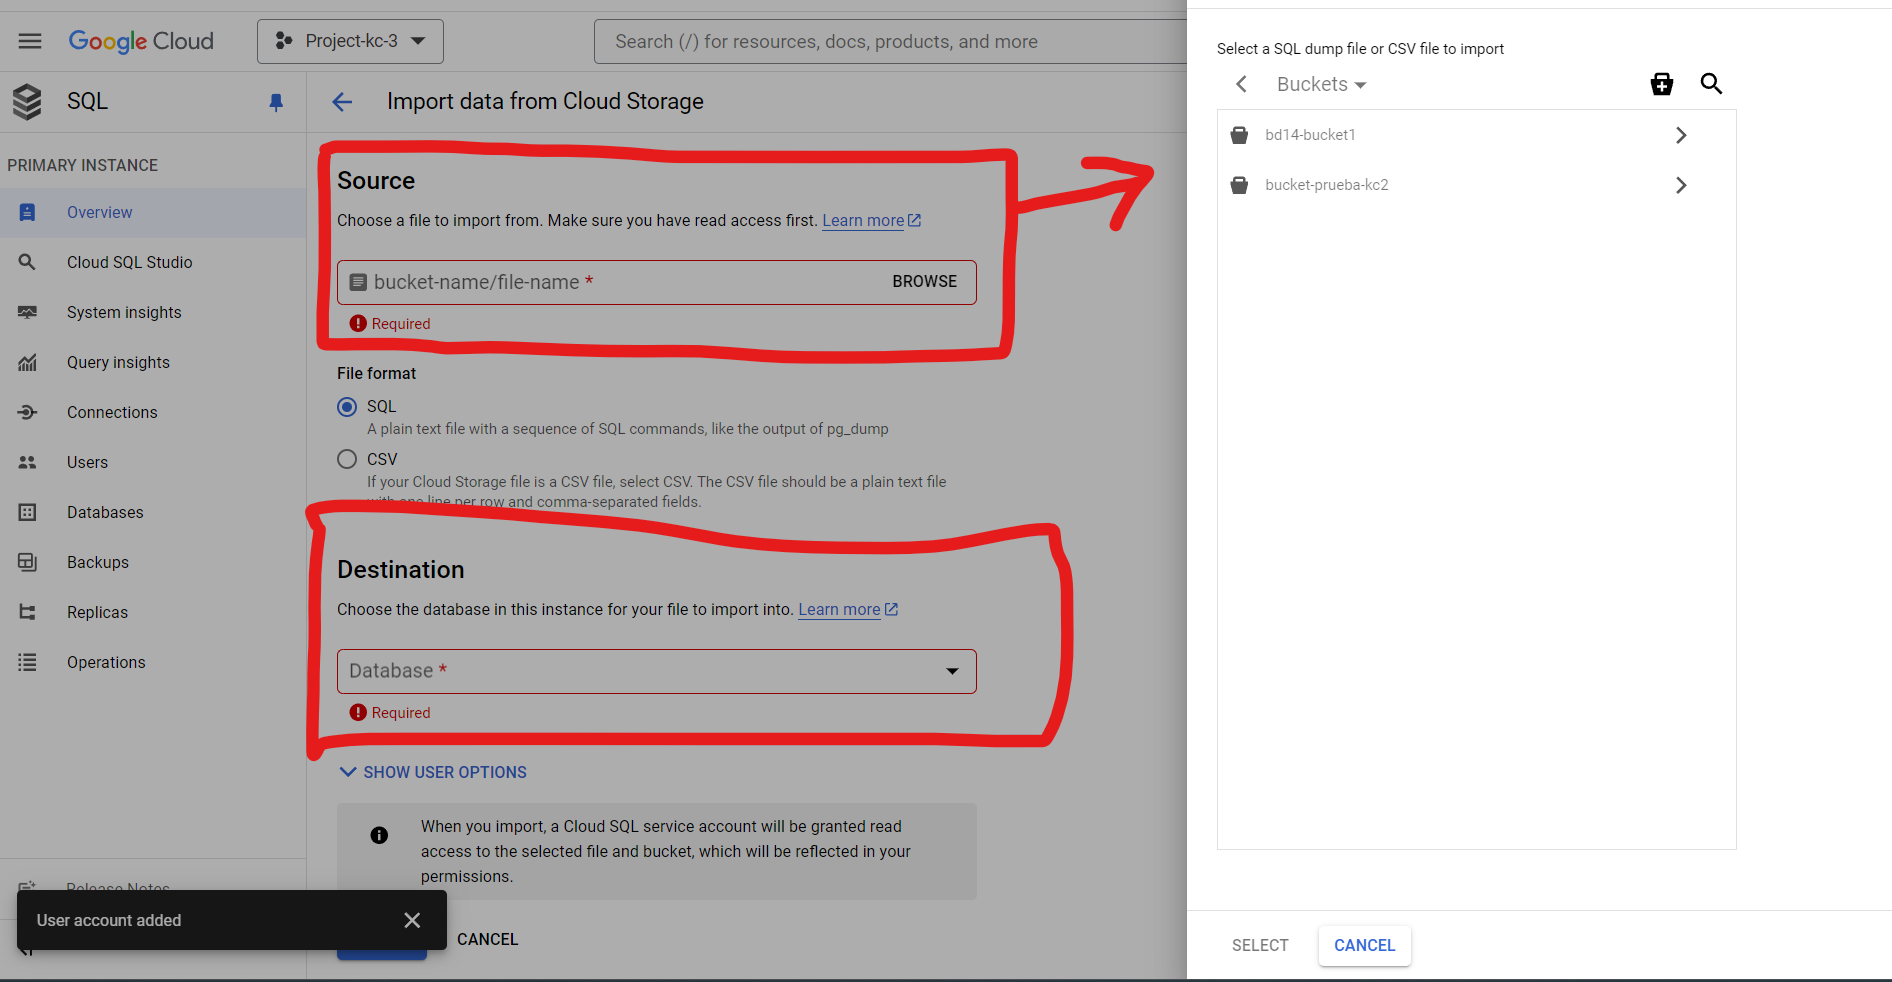

(No olvidemos seleccionar también el usuario en la importación)

3- **Si la importación fue exitosa, en "Operations" veremos un log de confirmación, en caso contrario, veremos uno de fallo. En la siguiente imagen se ven ambos:**

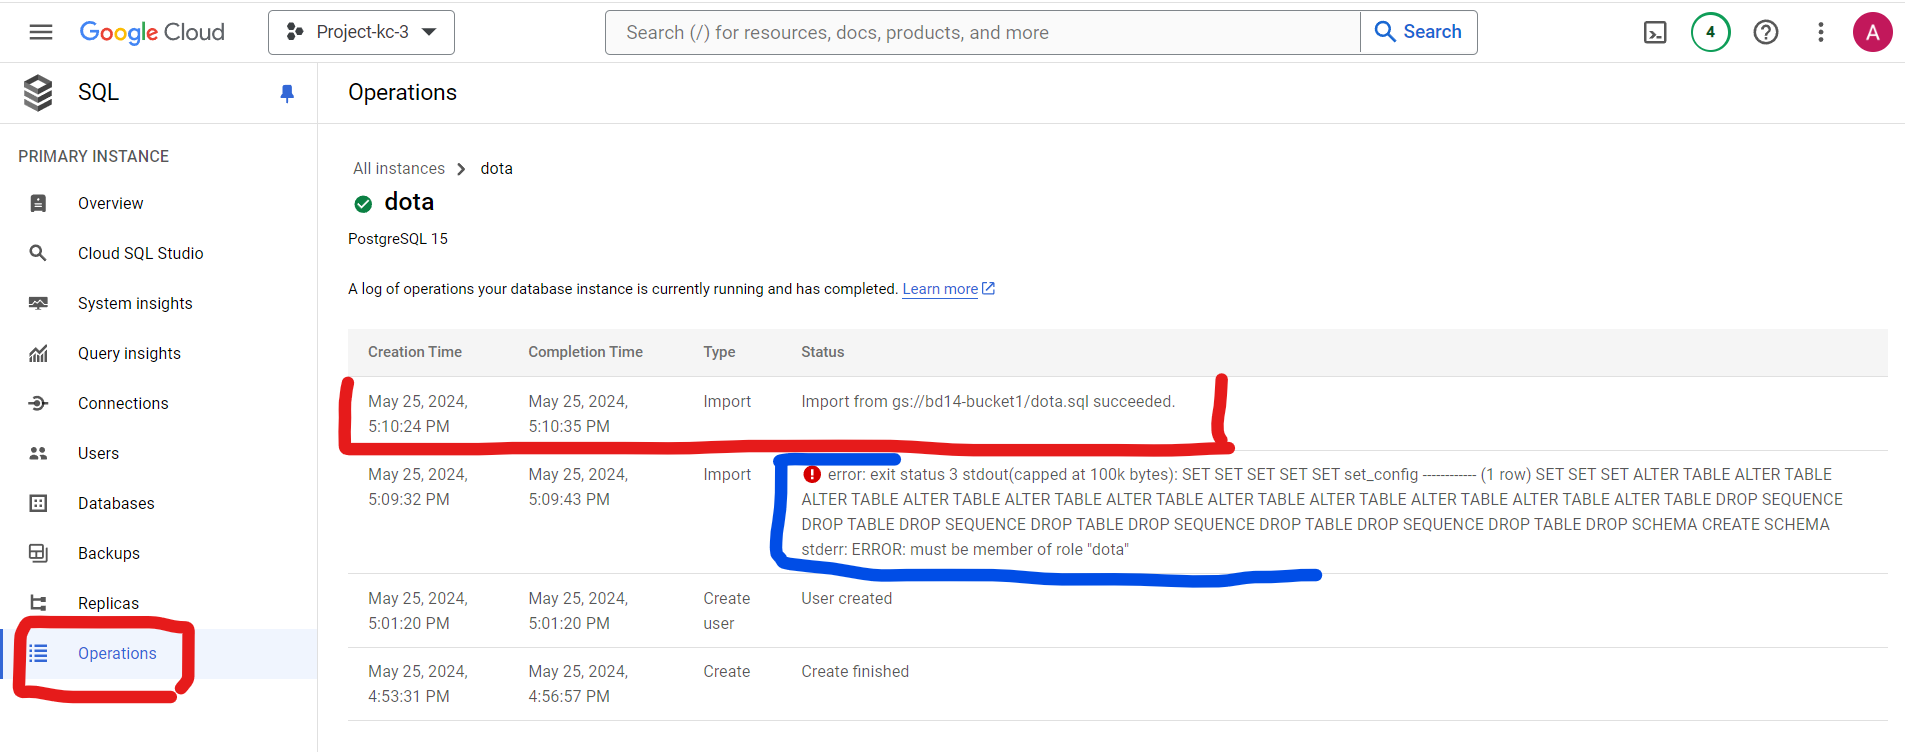

# Probemos la **conexión**!

Vamos a hacer un chequeo rapido para ver si esta todo correcto. Una **consulta** a la base de datos que acabamos de crear:

In [ ]:
!curl ipecho.net/plain

35.197.120.210

In [ ]:
# Tratemos de conectarnos y probar con una consulta directa a la tabla pg_database de PostgreSQL que contiene los nombres de las bases de datos existentes

# El host será la IP pública de la base de datos a la que nos queremos conectar. Esta IP la encontramos en Overview en nuestra nueva instancia

import psycopg2
from psycopg2 import sql

conn = psycopg2.connect(dbname='postgres', user='dota', password='password', host='34.88.249.70')#Quien aloja la BBDD consola Google de IP Dirección IP pública
cur = conn.cursor()

cur.execute(sql.SQL("SELECT * FROM pg_database WHERE datname = 'postgres'"))
exists = cur.fetchone()

if exists:
    print("La base de datos 'postgres' existe.")
else:
    print("La base de datos 'postgres' no existe.")

La base de datos 'postgres' existe.


In [ ]:
# Printeemos algo de la propia base de datos:

import psycopg2
conn = psycopg2.connect("dbname=postgres user=dota password=password host=34.88.249.70") #Ojo el mismo que el que figura en la consola Google de IP Dirección IP pública
postgres = conn.cursor()
postgres.execute("select * from heroes")
postgres.fetchone()#dame uno de los heroes de la BBDD SQL

(14,
 'Juggernaut',
 'Agility',
 "Dota Allstars: Slicing through armor with the greatest of ease. Whirling, dancing like a dervish, swiping foes with a flick of the wrist. Poetry in motion, slashing enemy upon enemy in the blink of an eye. Yurnero seeks perfection. Seeks to become one with his blade. All to fulfill his destiny as the unstoppable Juggernaut. Dota 2: No one has ever seen the face hidden beneath the mask of Yurnero the Juggernaut. It is only speculation that he even has one. For defying a corrupt lord, Yurnero was exiled from the ancient Isle of Masks--a punishment that saved his life. The isle soon after vanished beneath the waves in a night of vengeful magic. He alone remains to carry on the Isle's long Juggernaut tradition, one of ritual and swordplay. The last practitioner of the art, Yurnero's confidence and courage are the result of endless practice; his inventive bladework proves that he has never stopped challenging himself. Still, his motives are as unreadable as

Todo funciona! 🎆 🎆

# Ahora vamos a crear una **Base de Datos NoSQL**!

## Vamos con **MongoDB**

Vamos a hacerlo un poco diferente.
Nuestro trabajo ahora será **crear esta base de datos en un server**

Para ello, necesitamos **CREAR UNA MÁQUINA VIRTUAL UBUNTU** y aplicar algunas reglas de **FIREWALL** que permitan el acceso solo a los clientes que nosotros queramos.

1- **Comencemos creando nuestra máquina virtual Ubuntu**

  1.1- Menú -> Compute Engine -> VM instances

  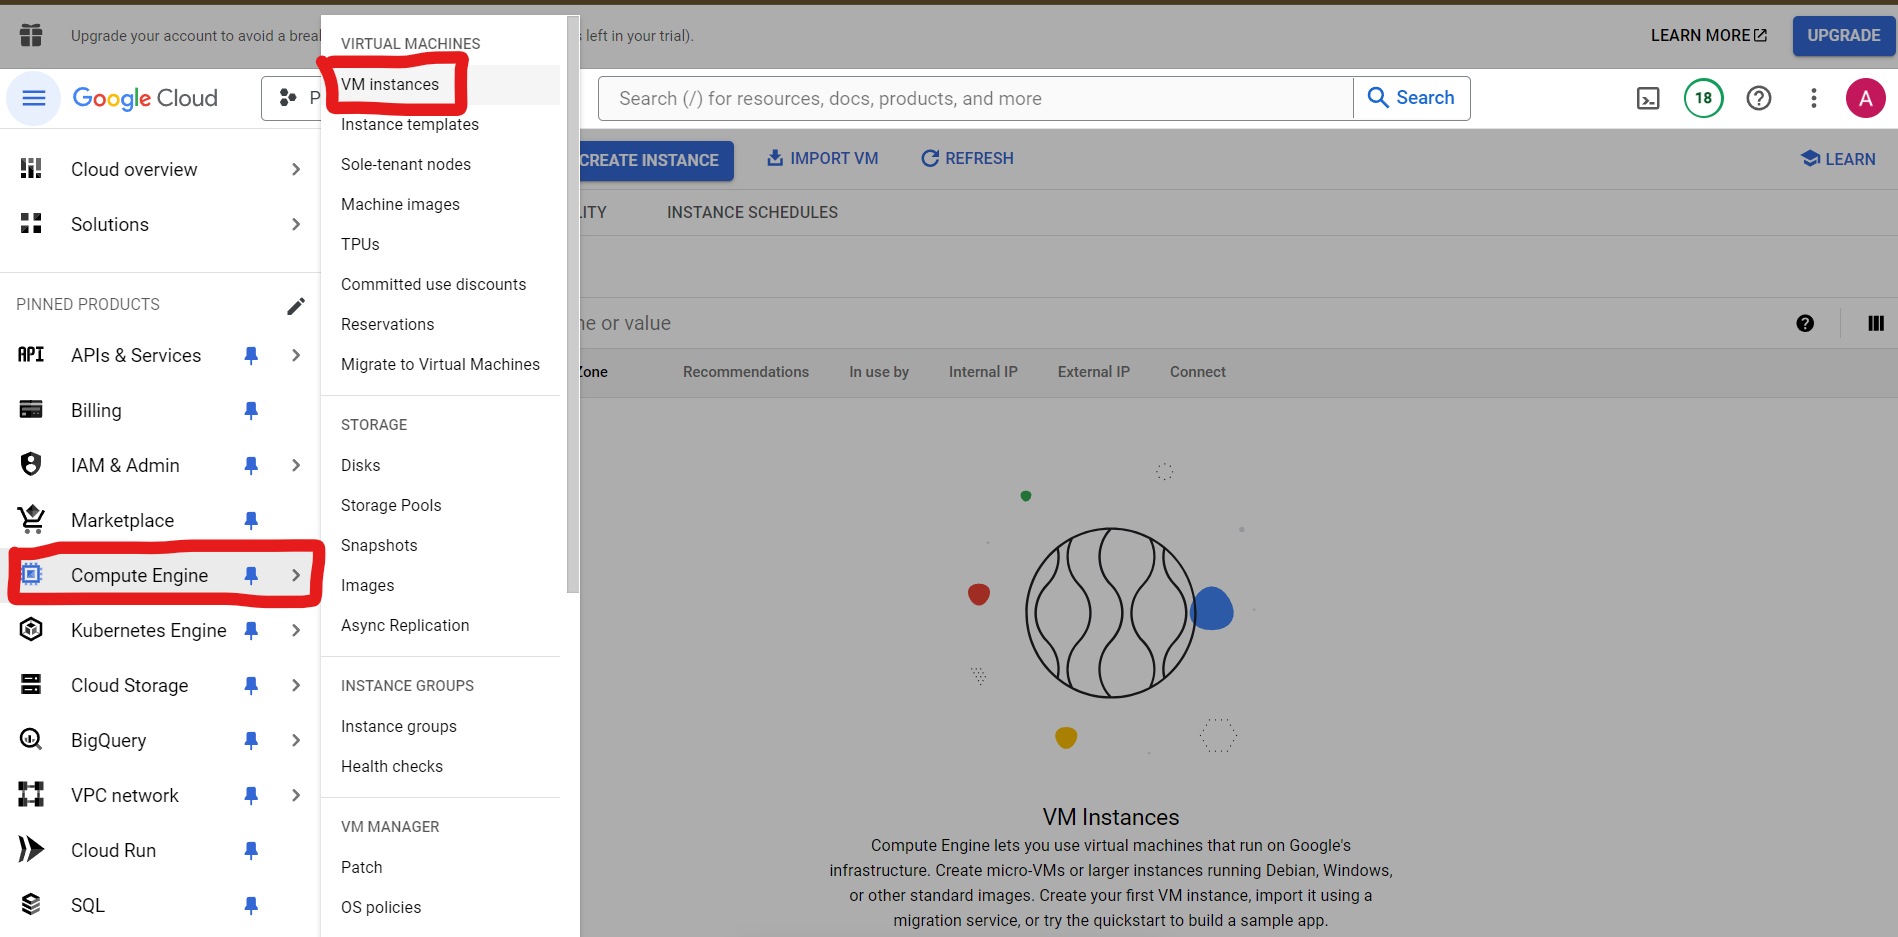

1.2- **Create instance**

Aquí vamos configurando la máquina

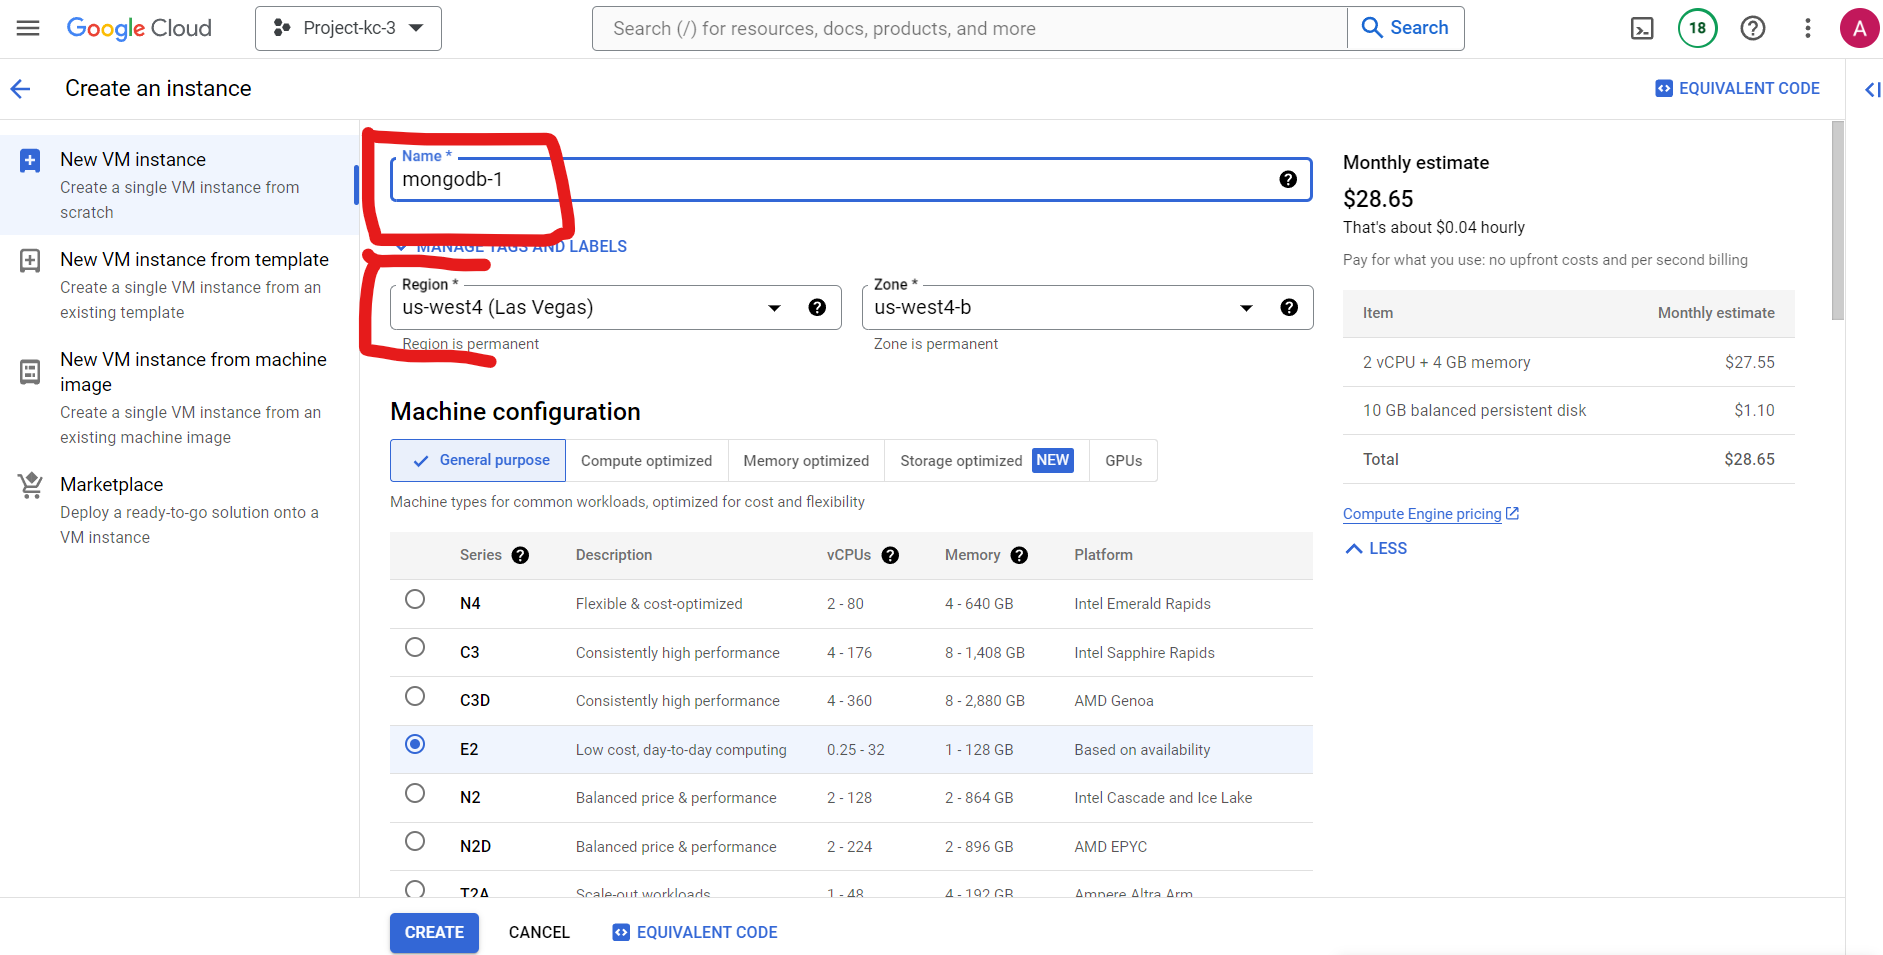

Atentos! Vamos a configurar la VM en Ubuntu, no en Debian:

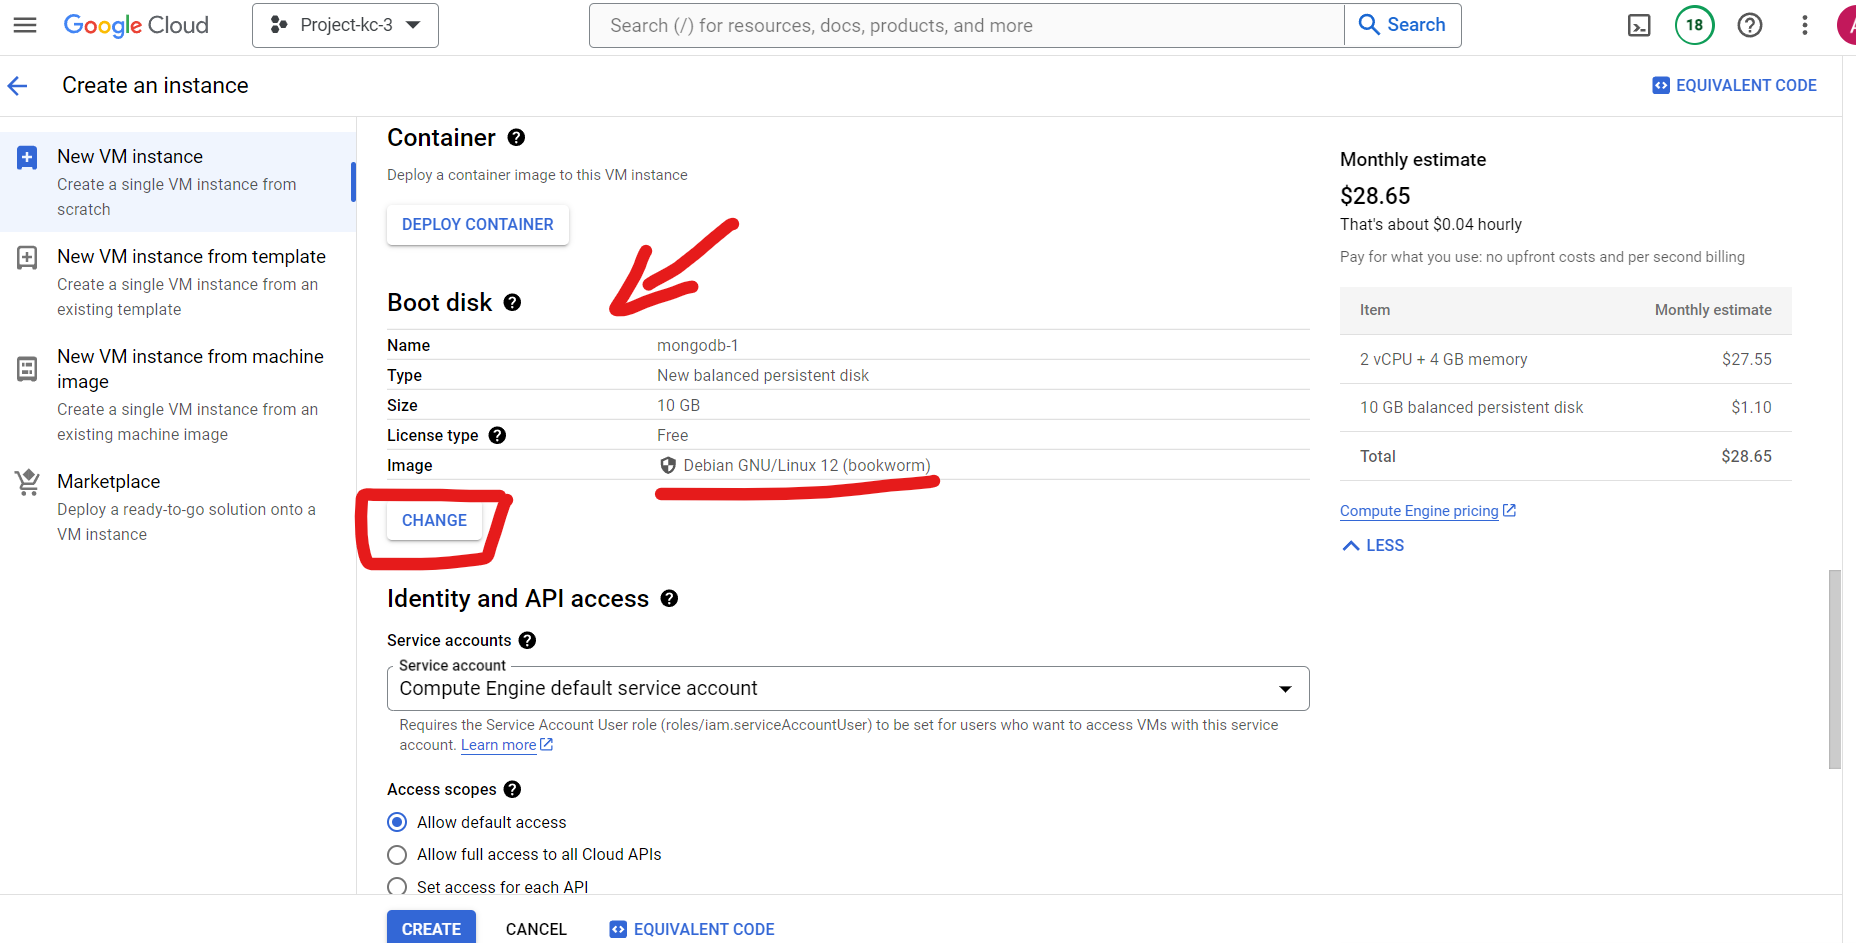


Una vez le damos a crearm la máquina se creará y aparecerá en nuestras VM instances:

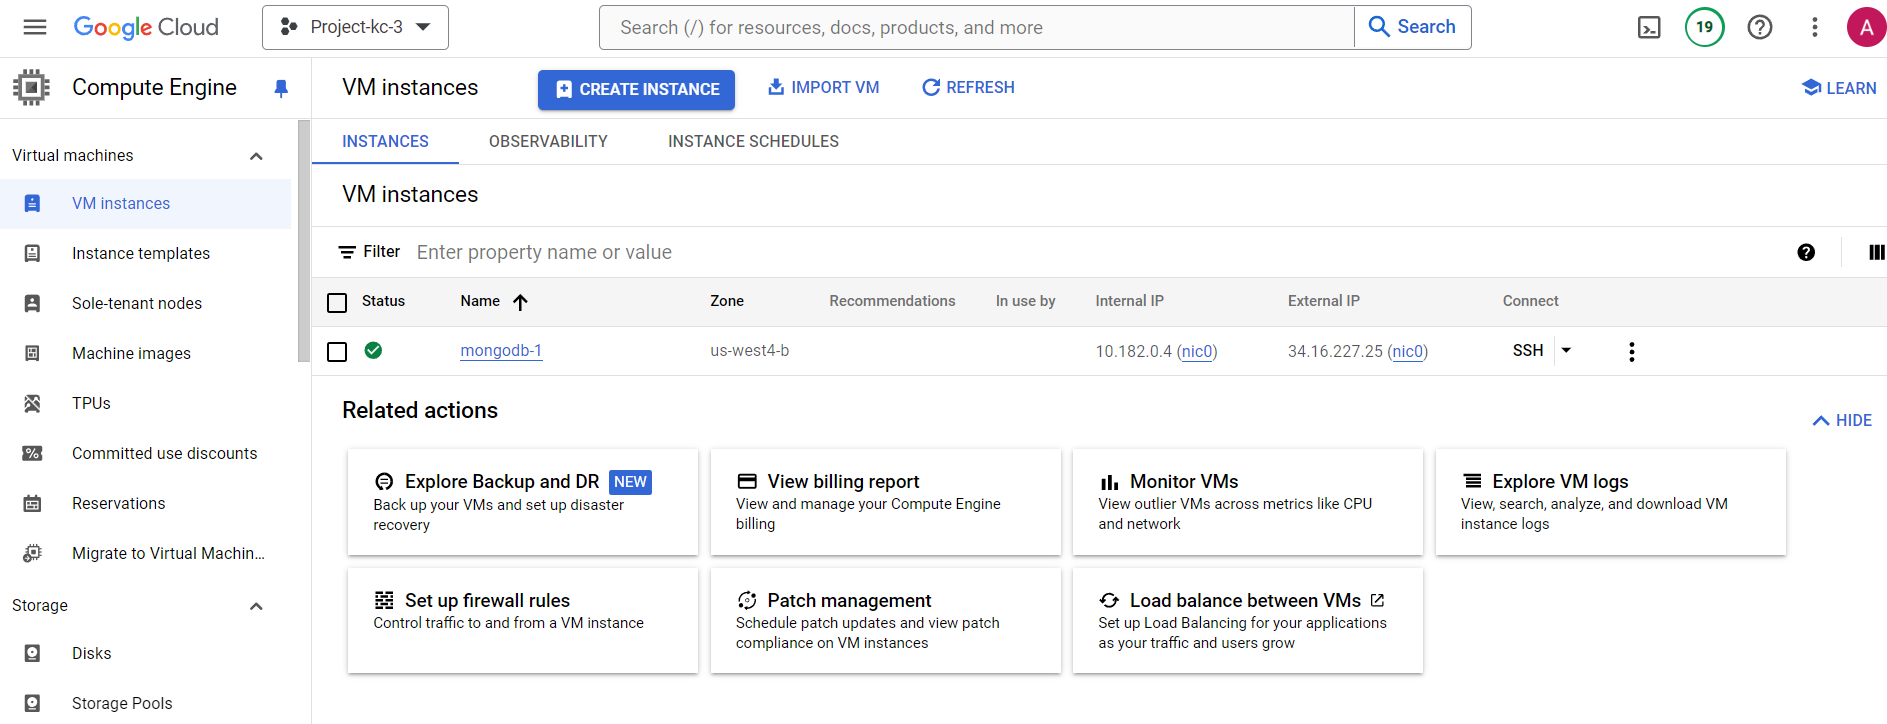

2- **Una vez creada la VM, vamos a crear las reglas de Firewall**

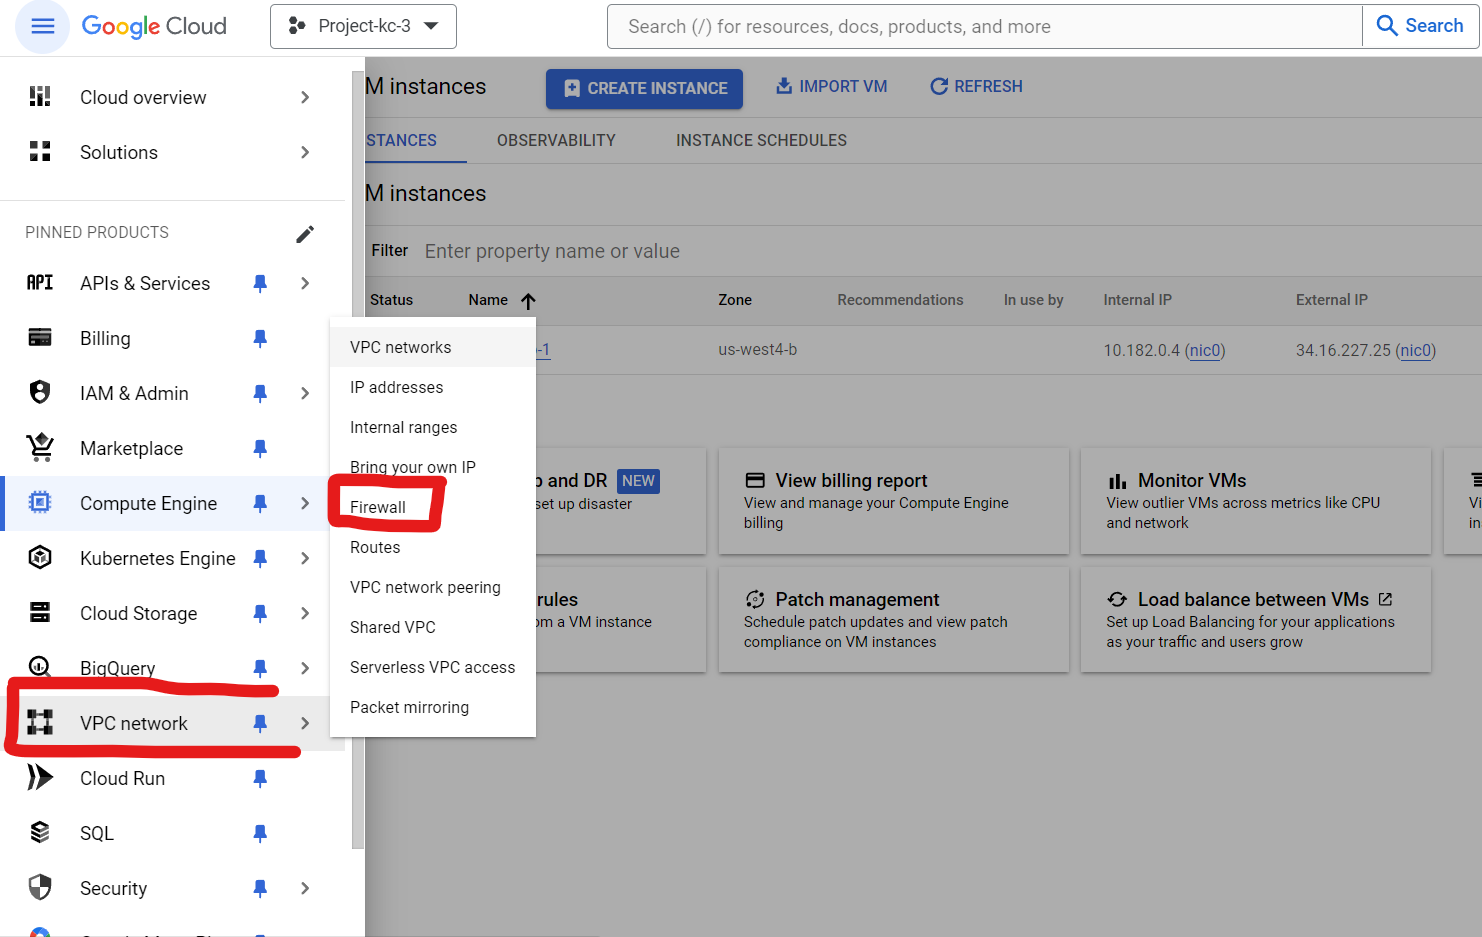

2.1 **Create Firewall Rule**

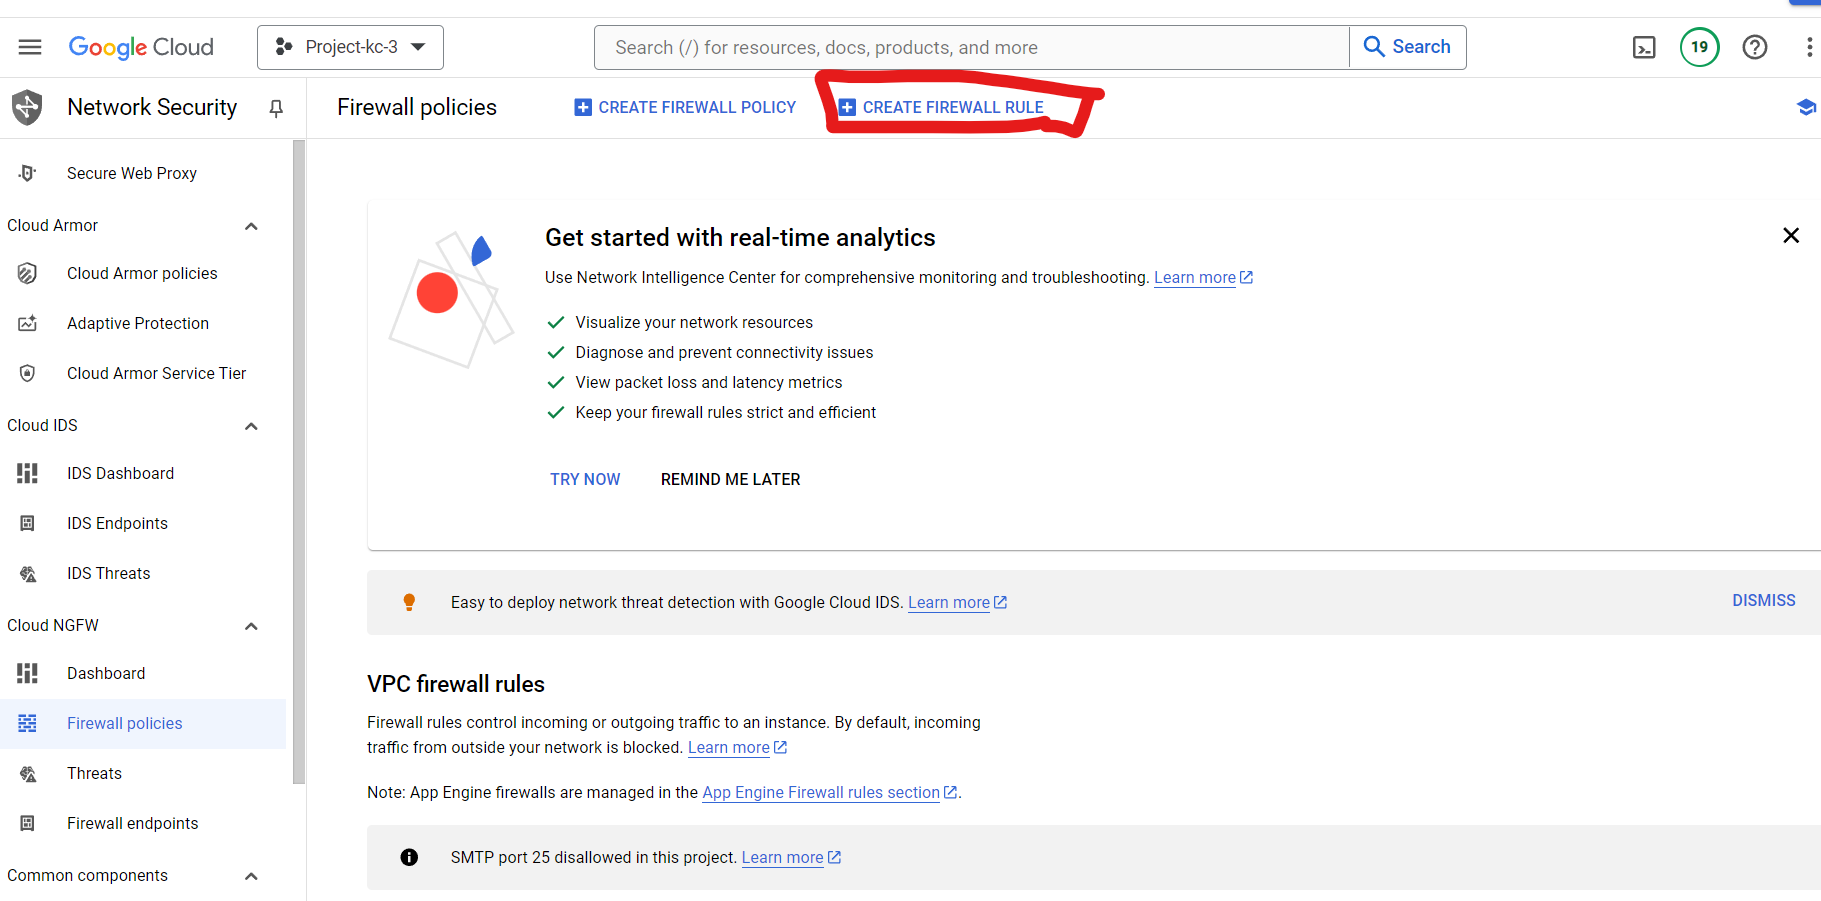

2.2- **Configuramos el nuevo firewall**

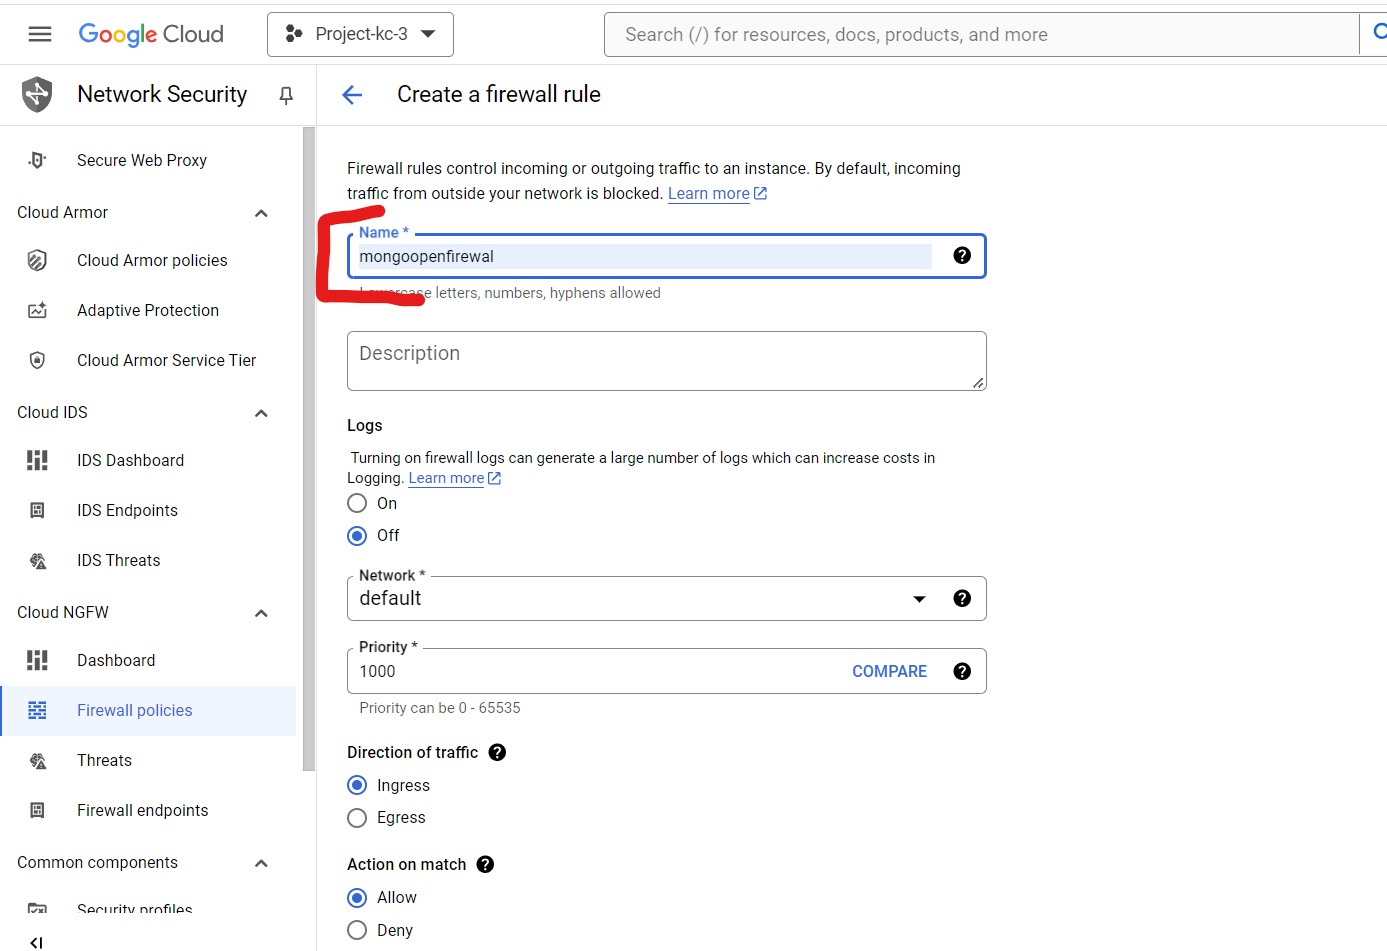

**Vamos a  necesitar indicar en el Firewall las IPs permitidas y los puertos**.

La **IP**, será la de **nuestro equipo local** desde el que después accederemos a la máquina virtual que acabamos de crear.

Existen algunas webs que nos dicen la IP de nuestro equipo. Recordad que esta cambia con el tiempo (es la que nos entrega nuestro proveedor de internet y es dinámica. Mañana no será la misma que hoy.

https://www.ipchicken.com/

El puerto... MongoDb escucha en el **puerto 27017**. Recordad!!!! **27017**

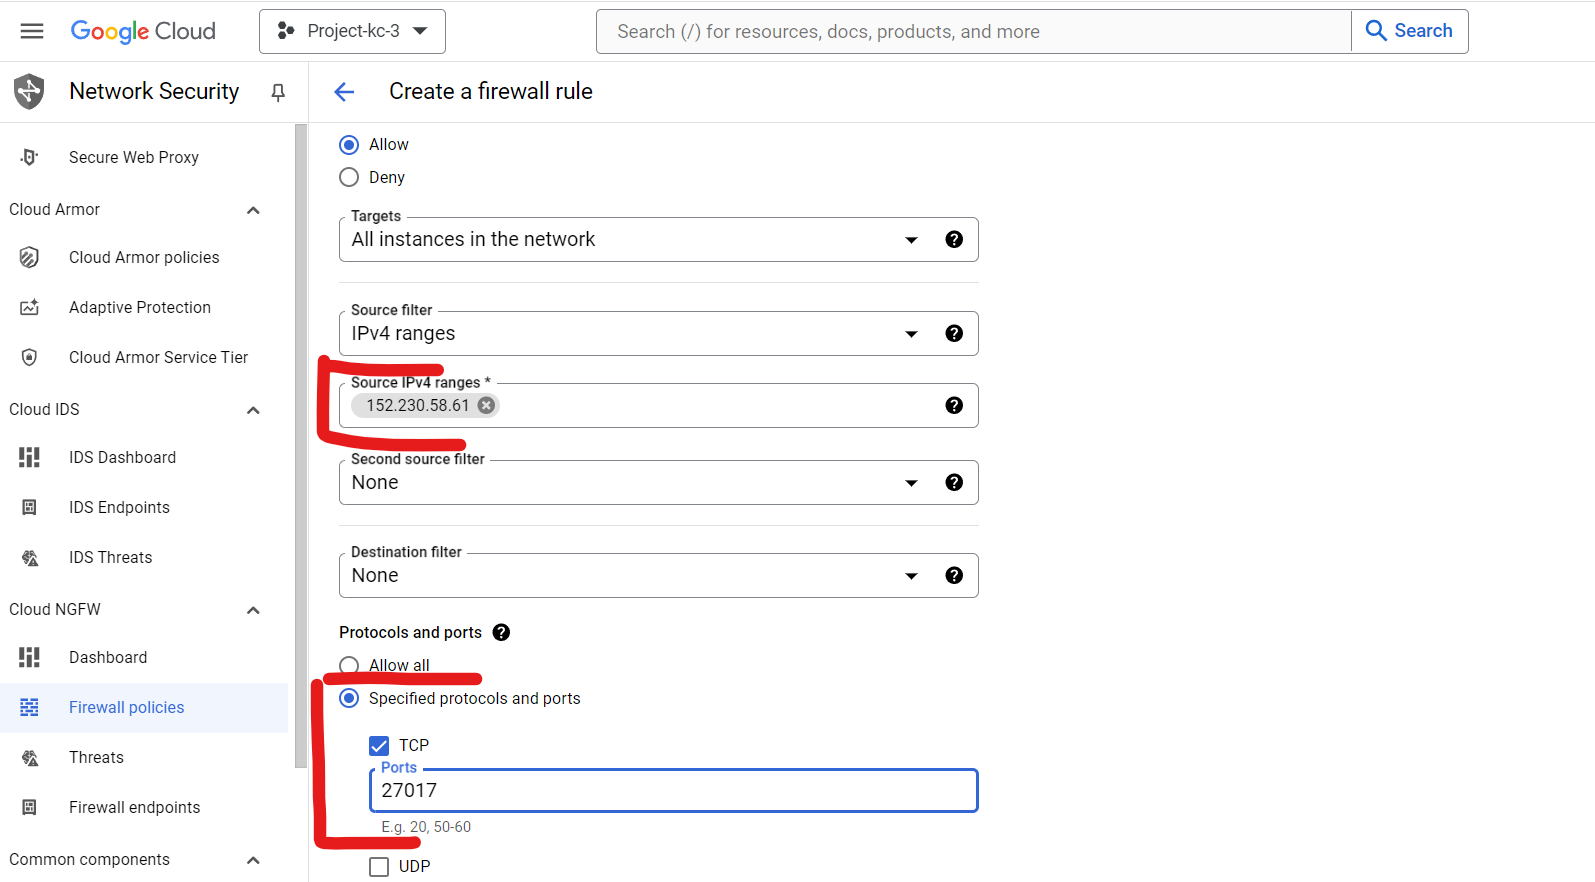

Una vez le demos a Create, nuestro Firewall quedará activado. Solo se podrá acceder a las VM que creemos desde las IPs y puertos que hemos indicado en nuestros Firewalls.

Vale, pues **ya tenemos nuestra Máquina virtual con Ubuntu y nuestro Firewall creados**. Ahora qué?

Ahora toca **instalar MongoDB en nuestra máquina virtual**!

1- Vamos a ver nuestra VM. (Recordad que está en **Compute Engine** -> **VM instances**)

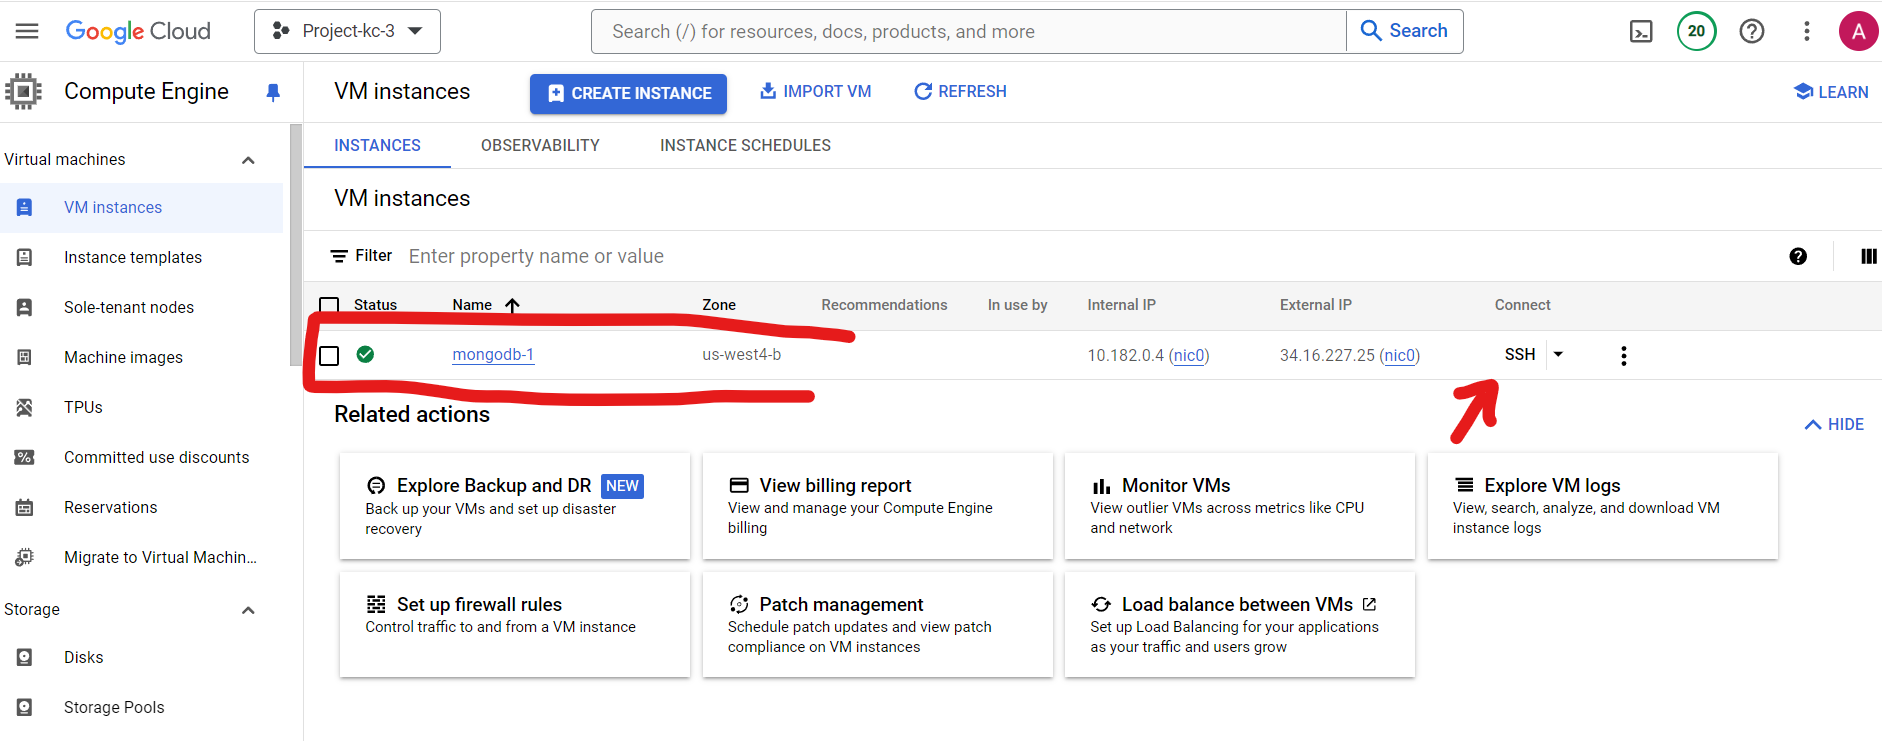

2- Hacemos click en **SSH**, y se abrirá la **consola** desde donde podemos controlar nuestra máquina virtual:

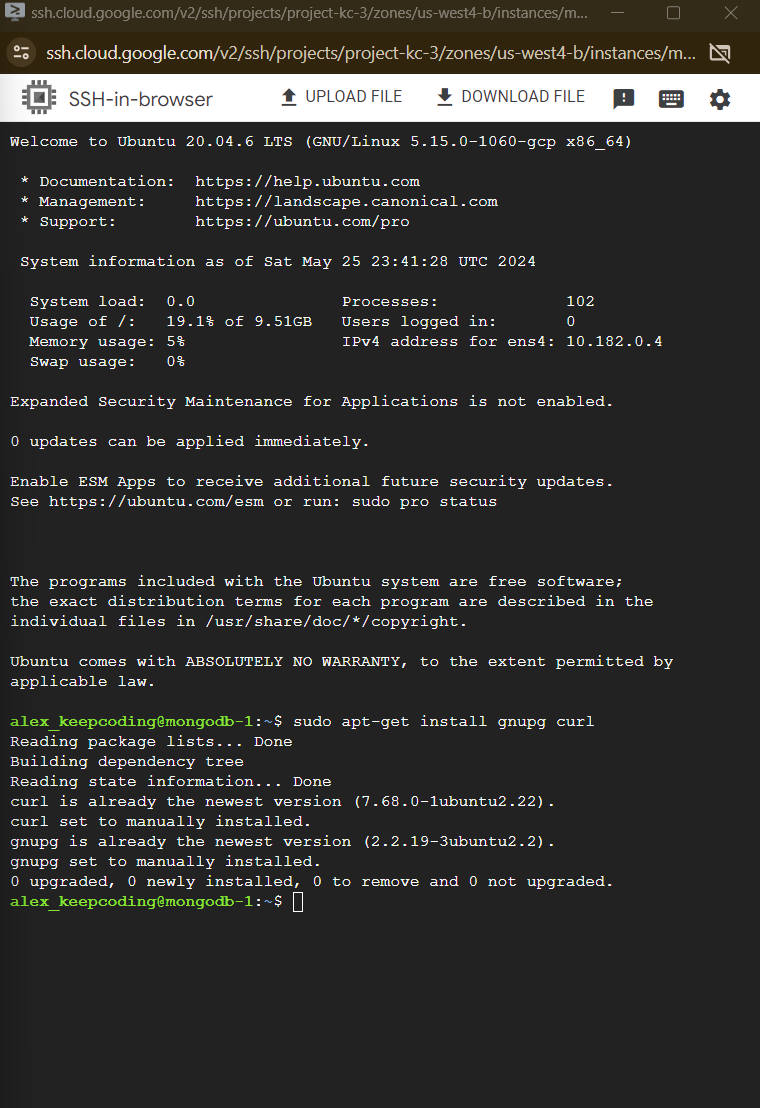

3- **Atención!** Debemos introducir los siguientes comandos en la consola para instalar MongoDB en nuestra máquina virtual

```
sudo apt-get install gnupg curl

curl -fsSL https://www.mongodb.org/static/pgp/server-7.0.asc | \
   sudo gpg -o /usr/share/keyrings/mongodb-server-7.0.gpg \
   --dearmor

echo "deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu focal/mongodb-org/7.0 multiverse" | sudo tee /etc/apt/sources.list.d/mongodb-org-7.0.list

sudo apt-get update

sudo apt-get install -y mongodb-org

```

4- **Una vez instalado MongoDB, vamos a configurarlo para que tenga salida a la red (por defecto solo tiene salida al localhost de la máquina donde está instalado, en este caso la VM)**

Para ello, accedemos al fichero de configuración de Mongo mediante la misma consola:

```
sudo nano /etc/mongod.conf
```

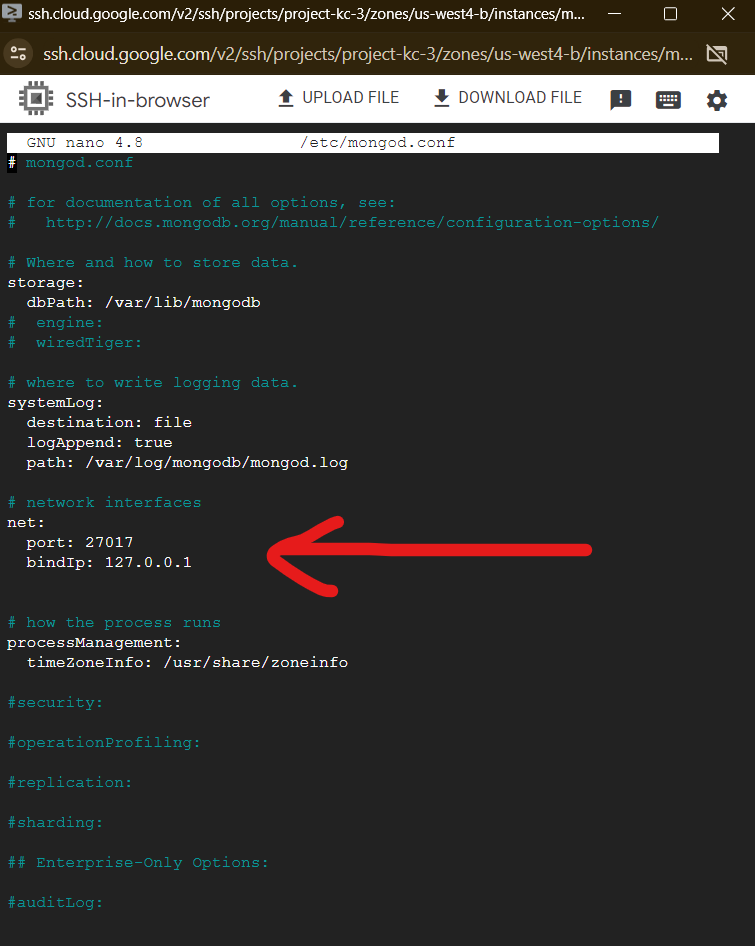

¿Veís? Mongo escucha por el puerto 27017
Aquí, **debemos cambiar bindIP y colocar 0.0.0.0**
(Tenemos el fichero abierto con el editor de texto Nano, debemos llegar a la linea mediante las flechas de nuestro teclado, aquí no funciona el mouse)

Ctrl+X para salir e Y para guardar cambios.

Debe quedar así:

```
net:
  port: 27017
  bindIp: 0.0.0.0

```

4- Por último, reiniciamos Mongo para que se apliquen los cambios.

```
sudo systemctl restart mongod

```

Listo! Ya tenemos **instalado** y **configurado** nuestro **server** con **MongoDB**!


Pero ahora queremos acceder desde cualquier lugar del mundo a nuestra VM para poder subir nuestro fichero con la base de datos ¿no?

Pues en nuestro equipo necesitamos **instalar MongoDB Compass**

https://www.mongodb.com/try/download/compass

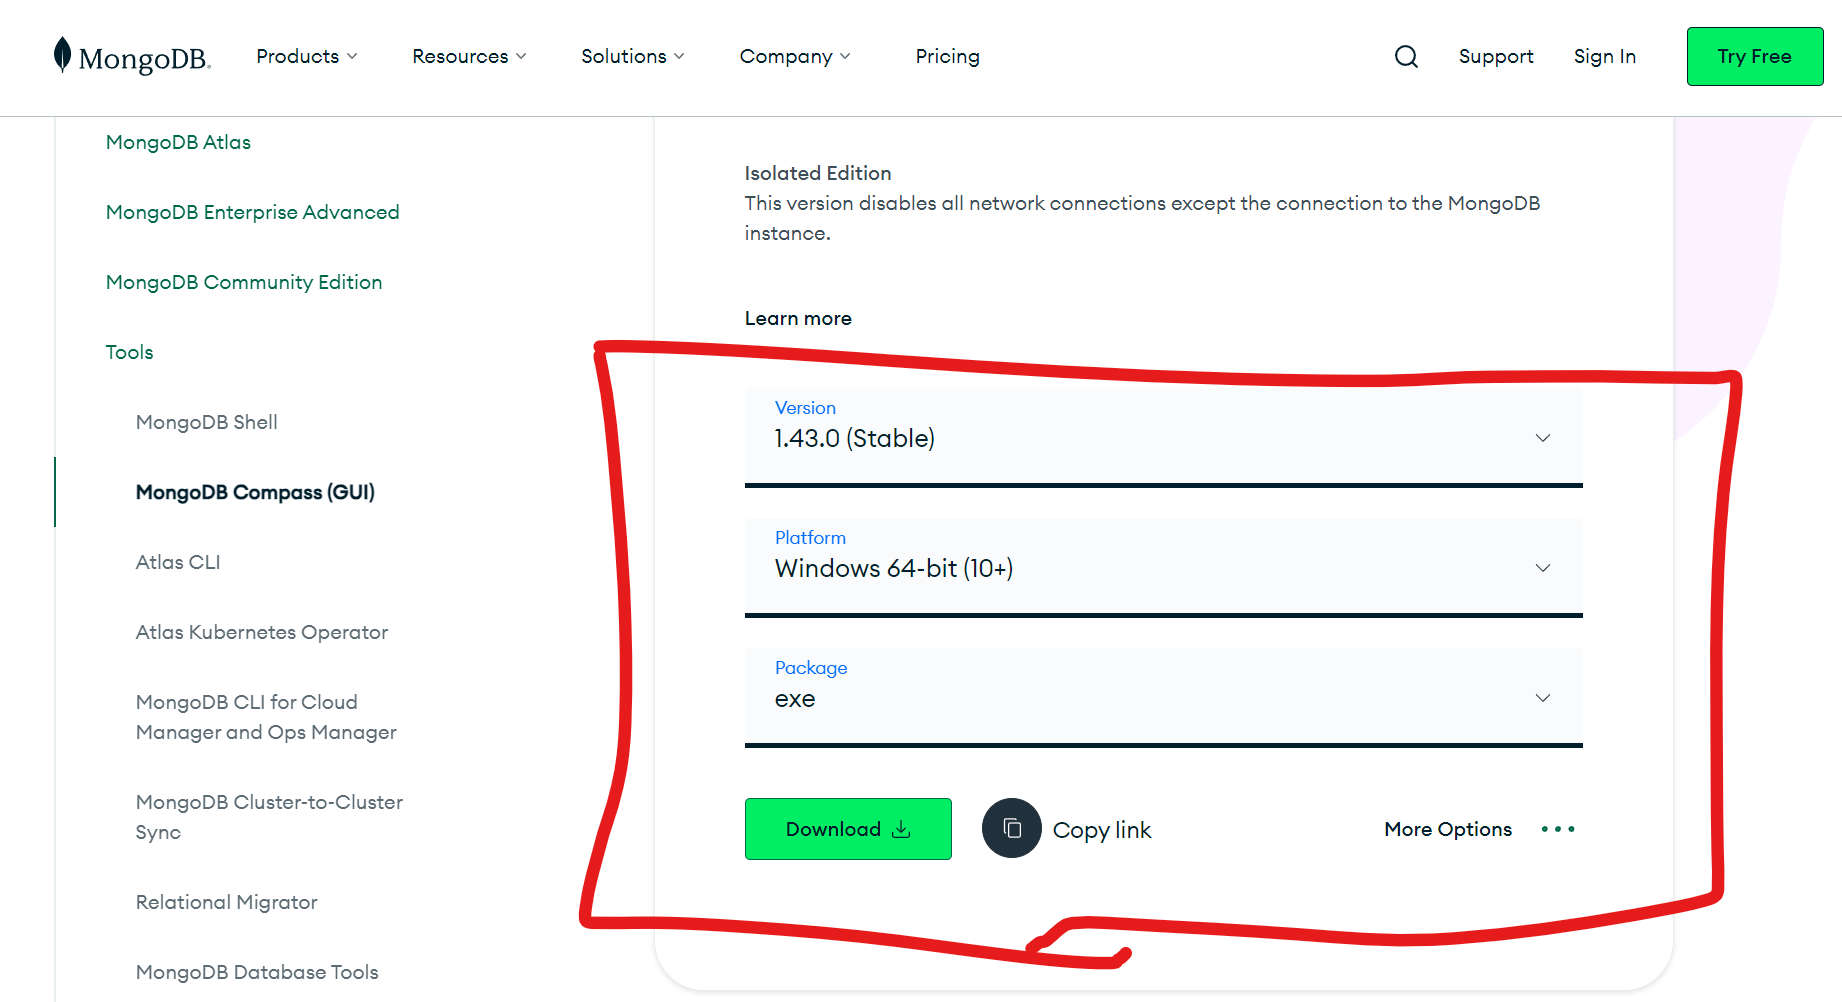

Una vez instalado, abriremos la aplicación (se abrirá sola seguramente):

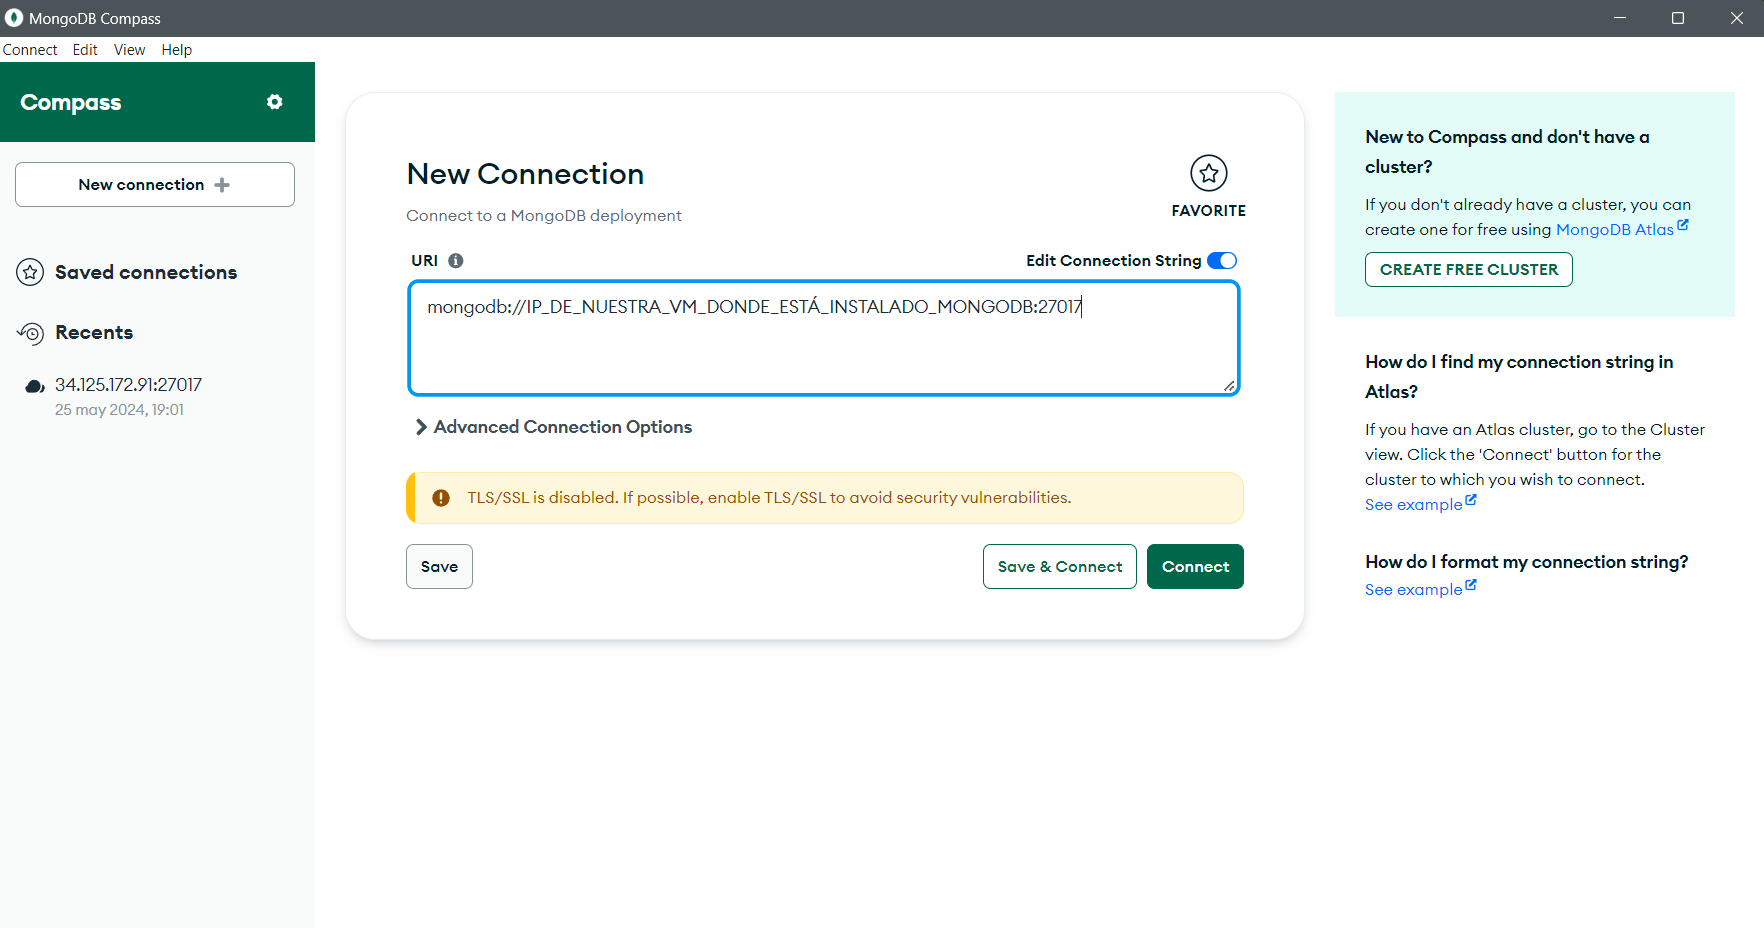


En la URI, debemos colocar la **IP pública de la máquina virtual**. Si recordais, la tenemos aquí:

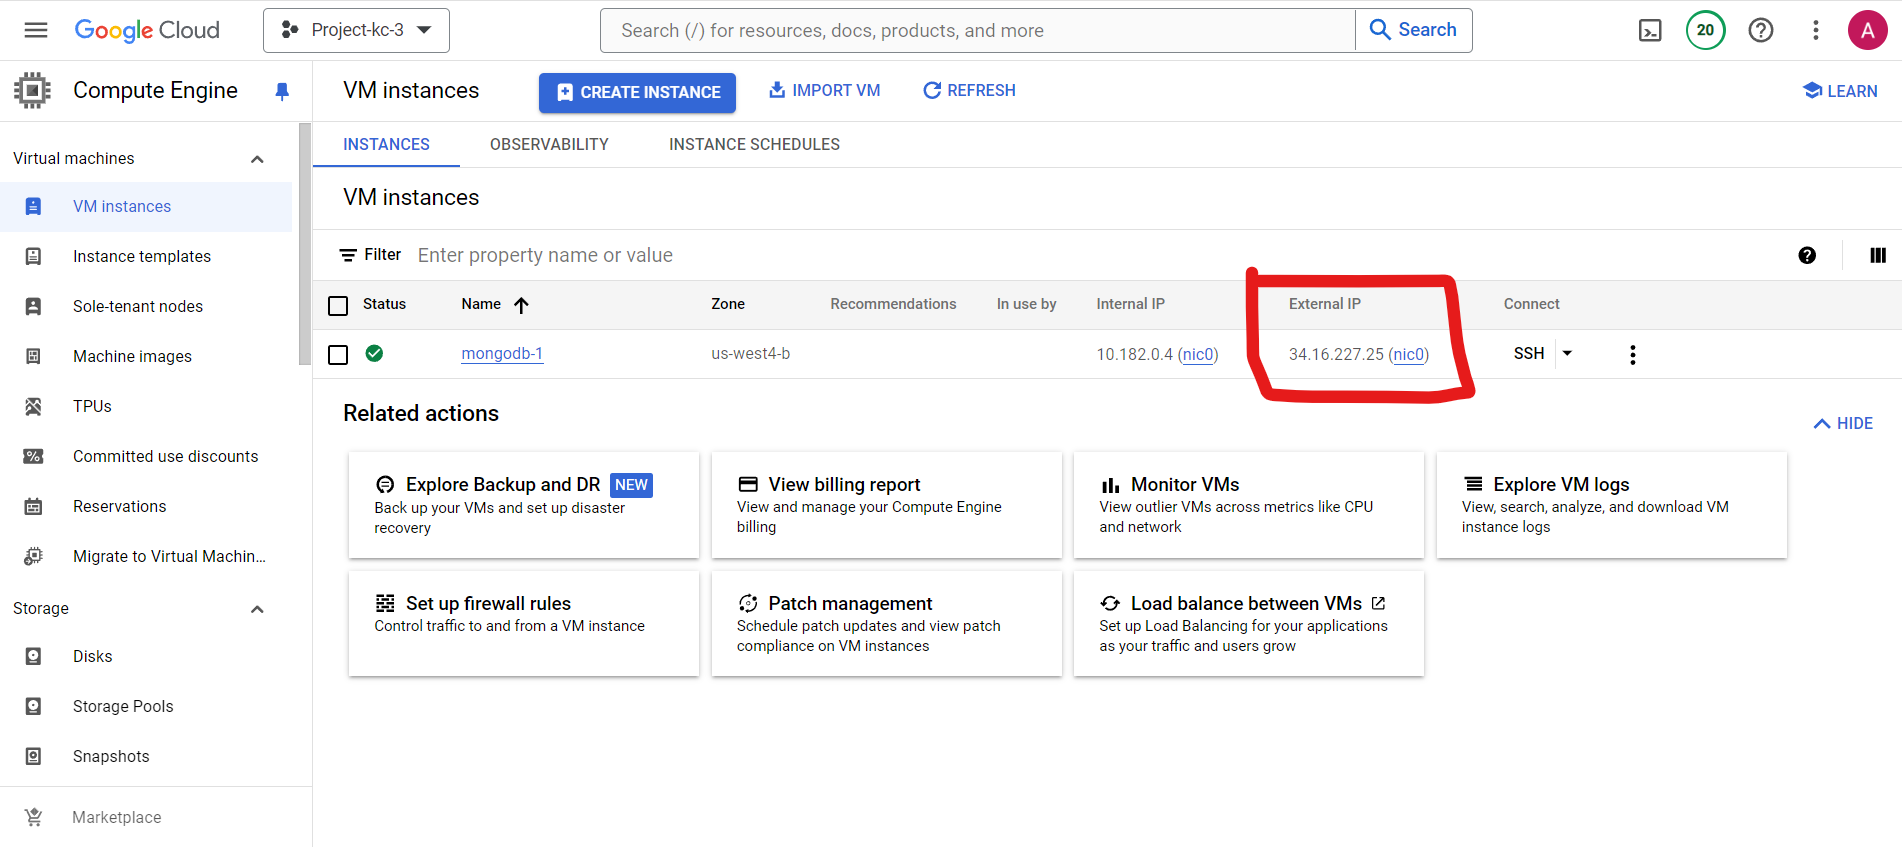

**Perfecto, se ha conectado!**

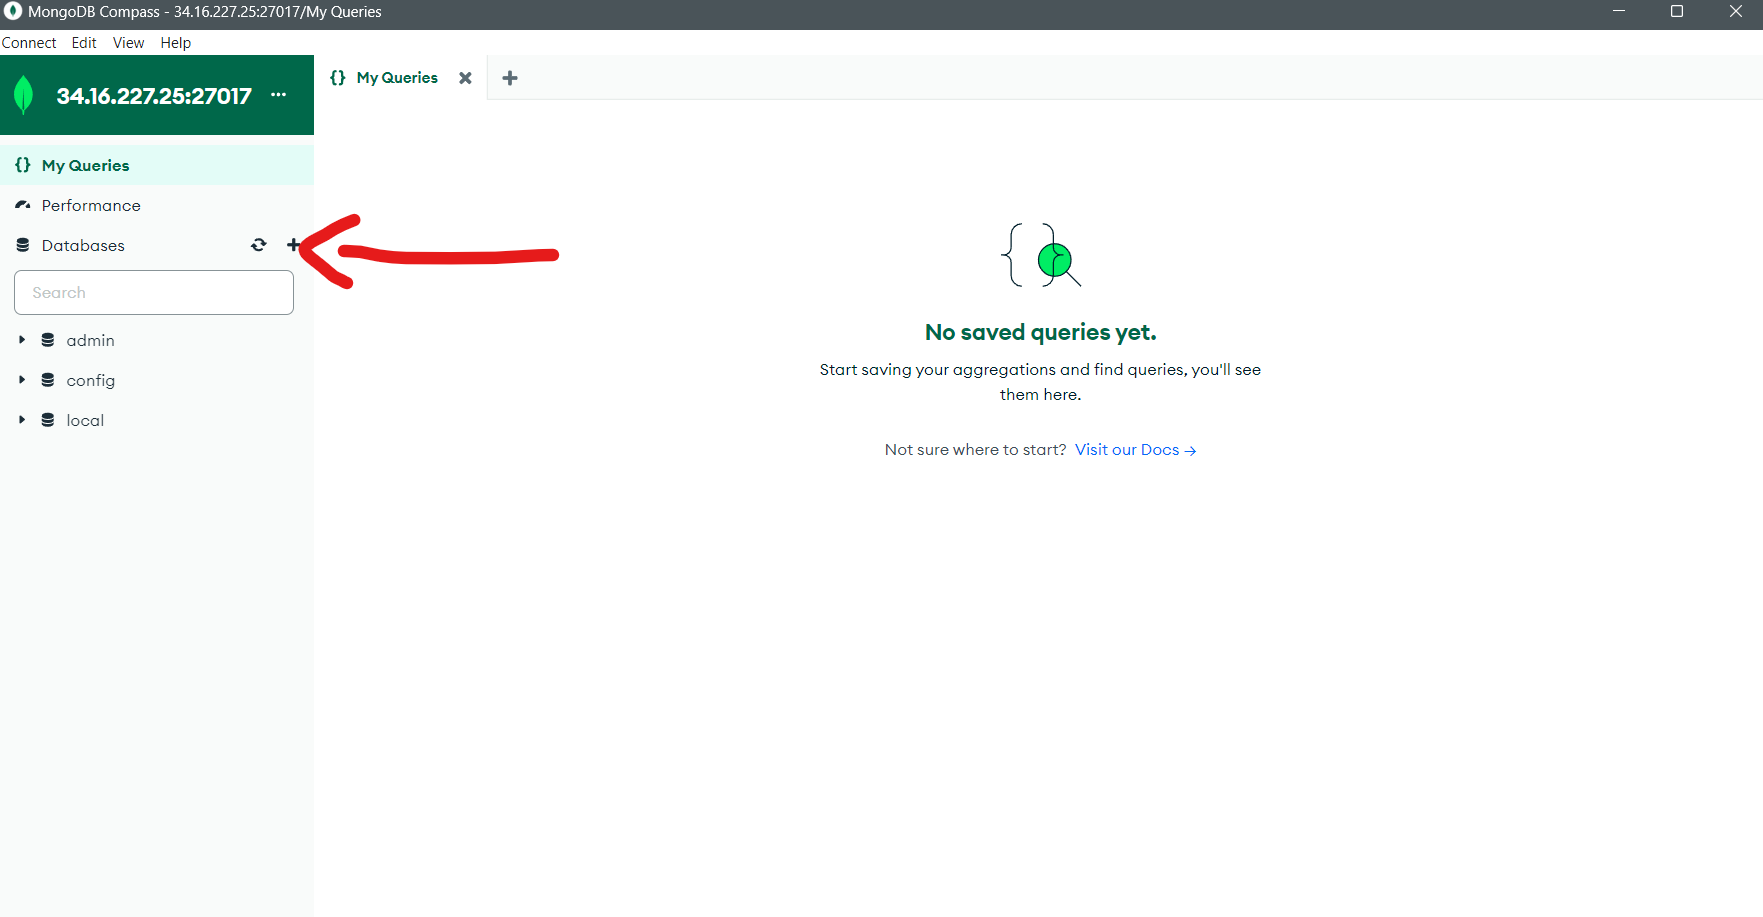


Ahora entonces, **agreguemos el dump de nuestra base de datos**:

Creamos la Database "dota" con la colección "heroes":

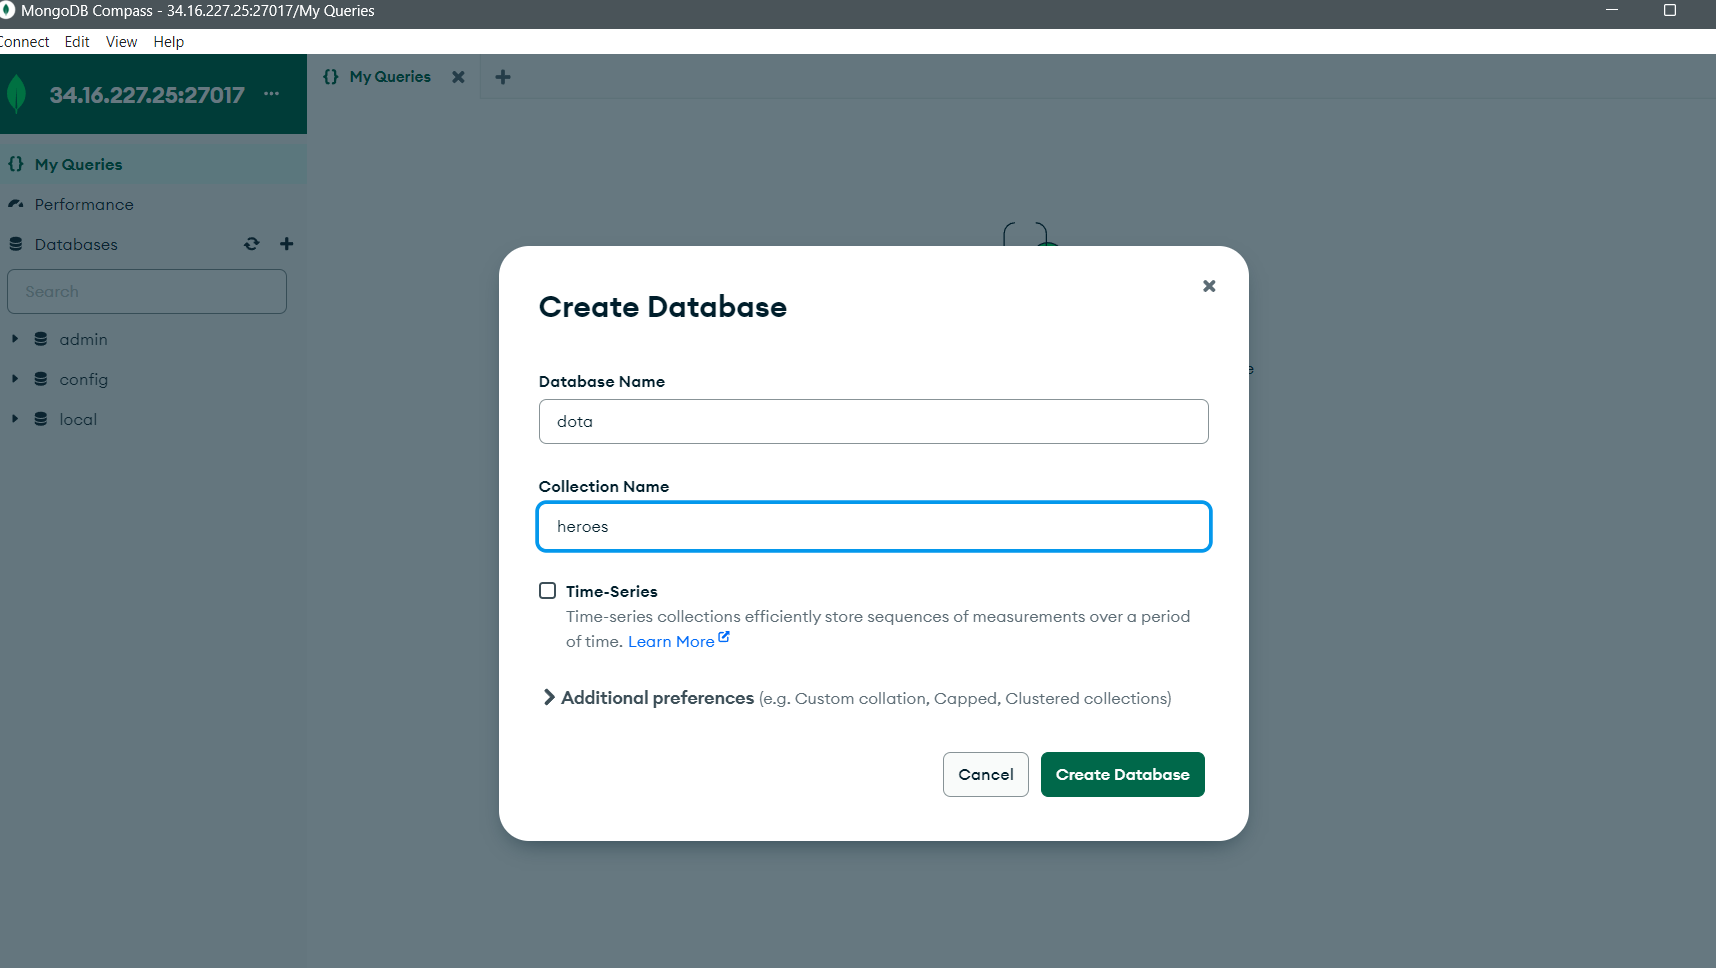


Una vez creada, tendremos que **importar los datos**. MongoDB acepta sin problemas los formatos **JSON y CSV**. Vamos a importar el archivo **heroes.json**:

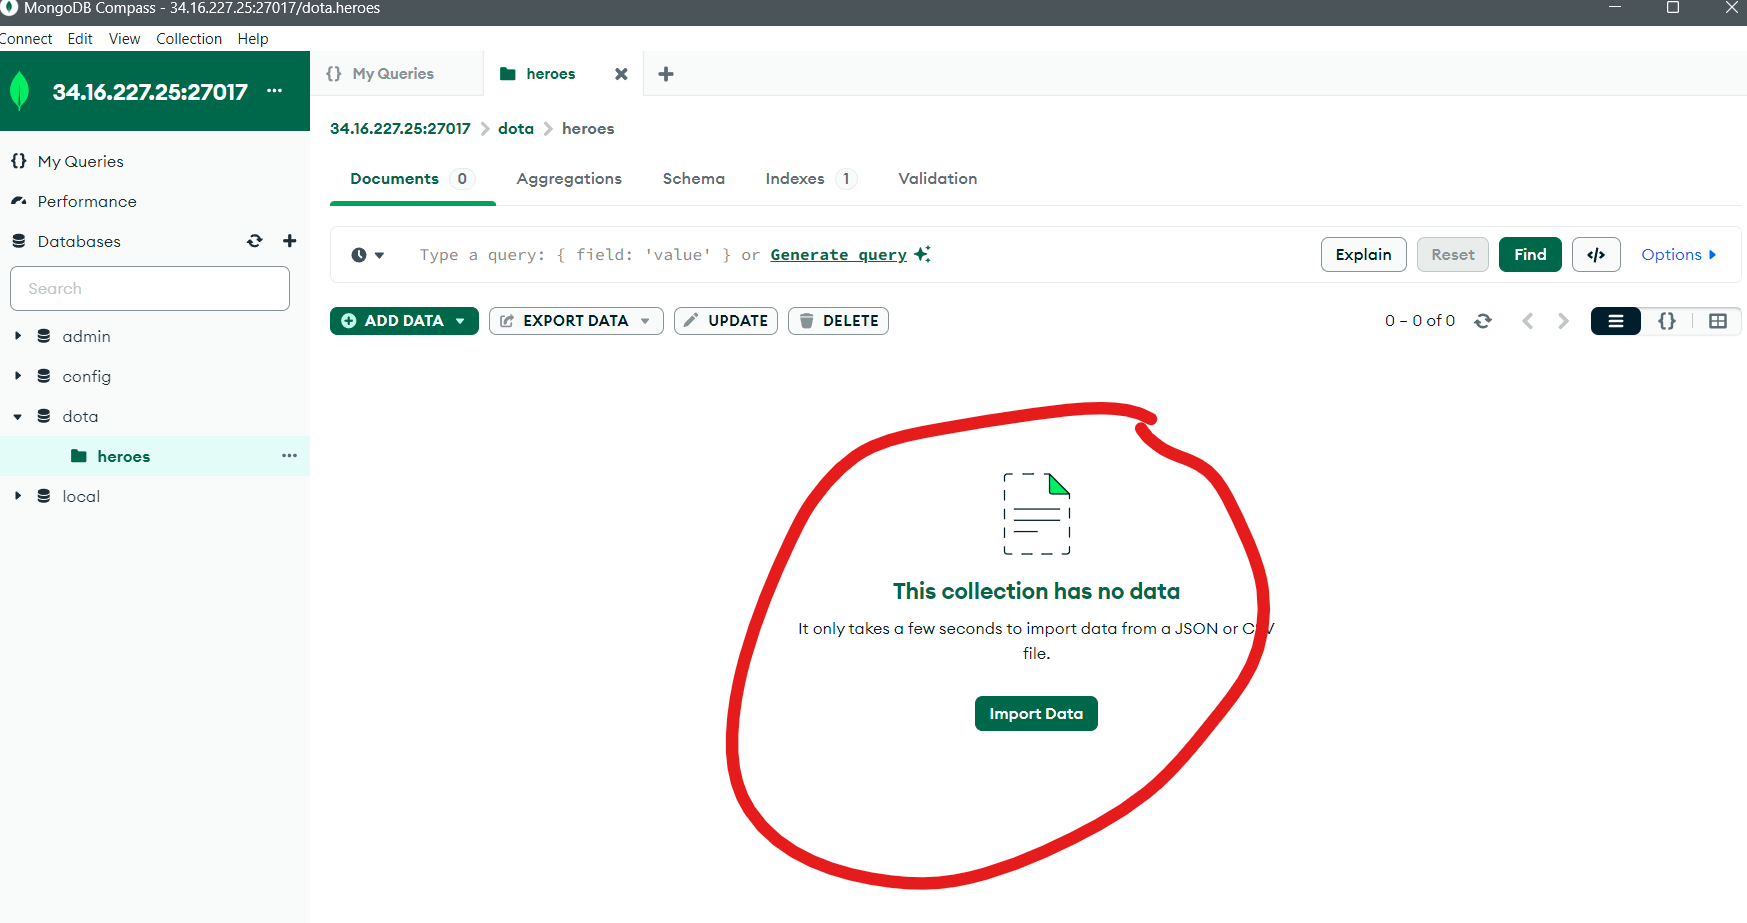

Ya está importada.
### Entonces, ya tenemos nuestro gestor de bases de datos creado en el servidor (nuestra máquina virtual), nuestras reglas de firewall para asegurarnos de que solo se puede acceder desde las IPs que le hemos indicado y a los puertos que le hemos permitido y además tenemos instalado en nuestro equipo (el cliente) Compass, que nos va a permitir desde remoto manejar este gestor de base de datos. Y ya que estábamos, hemos creado una base de datos y hemos importado una colección.

# ¡A probar **MongoDB**!

Finalmente probemos que podemos **conectar** y **seleccionar** los datos subidos.

Espera! Tenemos que crear una nueva **regla de firewall** para que nos permita acceder desde la **IP de este notebook**!

080325 Debemos de hacer una prueba con un modelo de datos de Mongo en local , una Maquina Virtual generada con Parallels.Seguir las instrucciones de Chatgpt.

OJO CON LOS PASOS DE CONFIGURACION EN LA CONSOLA NANO DE LA TERMINAL DE MONGO

In [ ]:
!curl ipecho.net/plain. #añadir la nueva ip en la consola para el firewall

35.194.219.3

In [ ]:
!pip install mongoengine pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 17.3 MB/s eta 0:00:00


In [ ]:
from pymongo import MongoClient
from pprint import pprint
client = MongoClient('34.147.123.244', 27017, directConnection=True)
mongodb = client.dota

In [ ]:
from pymongo import MongoClient

# Veamos las bases de datos existentes en mongo:
database_names = client.list_database_names()

print(database_names)

['admin', 'config', 'dota', 'local']


In [ ]:
# Hagamos una consulta:

mongodb.heroes.find_one({"name": "Tiny"})

{'_id': ObjectId('59402ce1bfa46541761e3b5a'),
 'lore': "Target Radius: 275 Damage: 25/35/45/55  Movement Speed Increase: 20/40/60  Dota Allstars: Looming from the rocky crags of Ashenra, the stone giants are born from the mountain itself. Tiny, a newly born giant, although small in size, has the strength of a hill. With his supreme strength, he is able to launch anything into the air, including huge amounts of soil to cause avalanches around his enemies. Because of his craggy exterior, enemies have a hard time attacking him. Over time, Tiny's body will grow bigger as the magnetic forces deep inside his granite heart pull rocks and soil to his rugged stone form. Dota 2: Coming to life as a chunk of stone, Tiny's origins are a mystery on which he continually speculates. He is a Stone Giant now, but what did he used to be? A splinter broken from a Golem's heel? A shard swept from a gargoyle-sculptor's workshop? A fragment of the Oracular Visage of Garthos? A deep curiosity drives him, and

PODRE CREAR UNA MAQUINA VIRTUAL EN PARALLELS PARA TENER UN ARCHIVO GRANDE DE MONGO Y PROCESARLO EN LOCAL ???



# **¡FELICIDADES!**

En este notebook has aprendido a crear tu base de datos en Cloud, SQL y NoSQL.
Además, has agregado y consultado datos.
Has configurado un servidor con una base de datos NoSQL en la nube y has configurado los firewalls para acceder a él.

El entorno cloud permite muchas opciones y soluciones que se pueden conectar a tu arquitectura o proyecto, solo es cuestion de seguir ciertos pasos para que nuestro modelo de operaciones tenga sentido.

